# 4.2. Medidas Descriptiivas y Estadísticas

## Bibliotecas y Port de Drive

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
pd.options.display.float_format = '{:.2f}'.format

drive.mount('/content/drive')

Mounted at /content/drive


## Lectura de Archivos

Tras recibir retroalimentación por parte de los profesores y del Socioformador, el equipo decidió incluir también la información del movimiento del inventario a nivel mensual, dictaminándolo como el Nivel Macro.

Esto representa, que el valor que ofrecerá el equipo, junto con los análisis, permitirá ver comportamientos tanto a nivel mes (Macro), como a nivel diario (Micro)

### Nivel Macro

Dataframe a nivel de detalle Mensual.

### Nivel Micro

Dataframe a nivel de detalle Diario.

In [ ]:
data_DanuStore_Mensual = pd.read_csv('/content/drive/MyDrive/DanuStore Equipo 6/data_DanuStore_Equipo6_Mensual.csv')
data_DanuStore_Diario = pd.read_csv('/content/drive/MyDrive/DanuStore Equipo 6/data_DanuStore_Equipo6.csv')

In [ ]:
data_DanuStore_Mensual.head()

,month,year,product_id,region,units_expected,stock,percentage,units_sold,sales_amount,product_name,category,subcategory,static_price,inventory_key,Ventas_Acumuladas_Mensual,Stock_Restante_Mensual,Cumplimiento_Venta_Esperada,Product_Repeat_Purchase_Rate,Venta_Promedio_Diaria,Dias_Cobertura_Inventario
0,March,2025,39,Bajío,1057,1735,164.14,107,4045.32,Shirts Product 39,Casual Wear,Shirts,45.40,Bajío_39_March_2025,107,1628,10.12,99.92,3.45,502.66
1,October,2025,46,Ciudad de México,1983,3215,162.13,671,49978.14,Pants Product 46,Casual Wear,Pants,87.10,Ciudad de México_46_October_2025,671,2544,33.84,99.89,21.65,148.53
2,May,2025,113,Ciudad de México,2549,4030,158.10,693,52325.53,Boots Product 113,Footwear,Boots,88.06,Ciudad de México_113_May_2025,693,3337,27.19,99.88,22.35,180.27
3,February,2025,75,Ciudad de México,1388,2192,157.93,355,23911.75,Jewelry Product 75,Accessories,Jewelry,79.43,Ciudad de México_75_February_2025,355,1837,25.58,99.84,12.68,172.89
4,October,2025,84,Ciudad de México,1458,2298,157.61,467,18204.74,Hats Product 84,Accessories,Hats,44.88,Ciudad de México_84_October_2025,467,1831,32.03,99.78,15.06,152.54


In [ ]:
data_DanuStore_Diario.head()

,stock_mov_id,date,day,month,year,region,product_id,product_name,category,subcategory,...,Client_Seniority_Years,Annual_Purchase_Frequency,Average_Ticket,Annual_Total_Spend,Discount_Usage,Preferred_Channel,Ventas_Acumuladas,Stock_Restante,Cumplimiento_Venta_Esperada,Repeat_Purchase_Rate
0,0,2024-01-01,1,January,2024,Ciudad de México,11,Tops Product 11,Fitness Wear,Tops,...,1.80,3,1499.08,4497.24,Medio,Tienda física,2,1809,37.94,100.00
1,1,2024-01-01,1,January,2024,Ciudad de México,65,Dresses Product 65,Casual Wear,Dresses,...,7.24,4,974.32,3897.28,Alto,Tienda física,2,2655,36.98,100.00
2,2,2024-01-01,1,January,2024,Ciudad de México,65,Dresses Product 65,Casual Wear,Dresses,...,1.73,10,1261.96,12619.60,Bajo,Tienda física,4,2653,36.98,100.00
3,3,2024-01-01,1,January,2024,Ciudad de México,65,Dresses Product 65,Casual Wear,Dresses,...,3.42,7,1299.43,9096.01,Medio,Tienda física,6,2651,36.98,100.00
4,4,2024-01-01,1,January,2024,Ciudad de México,65,Dresses Product 65,Casual Wear,Dresses,...,6.85,3,993.18,2979.54,Alto,Tienda física,7,2650,36.98,100.00


## I. Descripción de variables a analizar

Con el objetivo de que el análisis exploratorio permita consolidar un valor agregado para DanuStore, el equipo seleccionó **11 variables** dentro de los Dataframes, que permitirán ver la información tanto a nivel Macro como Micro, y encontrar patrones y tendencias.

La selección de las variables que presenta el equipo busca cubrir las diferentes áreas que engloba el reto, como **la gestión del inventario, el desempeño comercial de los productos, y el valor del cliente dentro de los mismos**.

Nota: Dado que la información disponible al día no incluye movimientos de abasto, el análisis del inventario aborda principalmente el **movimiento generado por las ventas,** que permite analizar comportamientos como que tanto se cumple la demanda esperada o como se desplaza el stock que queda al final del mes.

### 1.1. Variables Cualitativas

Las variables cualitativas describen **atributos o categorías** que permiten segmentar el negocio y comparar el comportamiento entre grupos.

| Variable | Descripción | Valor para el negocio |
|---|---|---|
| `category` | Línea de producto a la que pertenece cada artículo (Casual Wear, Footwear, Accessories, Fitness Wear). | Identifica qué segmentos del portafolio concentran la demanda y cuáles acumulan inventario, lo que orienta la asignación del presupuesto de compra y del espacio en piso de venta. |
| `region` | Zona geográfica donde se realiza la venta y se administra el inventario (7 regiones del país). | Muestra diferencias de demanda entre plazas y permite redistribuir inventario de regiones con excedente hacia regiones con mayor rotación, reduciendo costos logísticos. |
| `Client_Category` | Nivel de membresía o lealtad del cliente (Básico, Silver, Gold, Premium). | Evalúa si el programa de lealtad realmente agrupa a los clientes de mayor valor y dónde conviene concentrar beneficios y estrategias de retención. |
| `Preferred_Channel` | Canal por el que el cliente prefiere comprar (Tienda física, Online, App). | Dicta la estrategia omnicanal: dónde invertir en marketing digital, qué inventario se asigna a tienda contra e-commerce y cómo priorizar la experiencia de compra. |
| `Socioeconomic_Level` | Estrato económico del cliente (Bajo, Medio-Bajo, Medio, Medio-Alto, Alto). | Permite alinear precios, promociones y mezcla de producto con el poder adquisitivo real de la base de clientes. |

### 1.2. Variables Cuantitativas Discretas

Las variables discretas toman únicamente **valores enteros que no pueden fraccionarse**: no existe la venta de "1.5 prendas" ni una "media compra" al año. Por ello se analizan mediante tablas de frecuencia y gráficos de barras.

| Variable | Descripción | Valor para el negocio |
|---|---|---|
| `units_sold` | Número de piezas vendidas en cada transacción (Nivel Micro). | Mide el **volumen de movimiento** del inventario y el tamaño típico de la canasta de compra; identifica oportunidades de venta cruzada y promociones por volumen. |
| `Annual_Purchase_Frequency` | Número de compras que realiza un cliente en un año. | Es el indicador principal de **lealtad y recurrencia**: distingue a los clientes ocasionales de los clientes frecuentes que sostienen el flujo de ventas. |

### 1.3. Variables Cuantitativas Continuas

Las variables continuas pueden tomar **cualquier valor dentro de un rango, incluyendo decimales**, ya que representan montos financieros, porcentajes o razones. Se analizan mediante histogramas, medidas de tendencia central y dispersión, y diagramas de caja.

| Variable | Descripción | Valor para el negocio |
|---|---|---|
| `sales_amount` | Ingreso en pesos generado por cada transacción (Nivel Micro). | Es la métrica central de ingresos; permite conocer el ticket típico de venta y detectar transacciones atípicas de alto valor. |
| `Annual_Total_Spend` | Monto total que gasta cada cliente en un año. | Funciona como aproximación del **valor del cliente (Customer Lifetime Value)** e identifica al segmento de clientes que más contribuye al ingreso. |
| `Cumplimiento_Venta_Esperada` | Porcentaje de las unidades proyectadas que realmente se vendieron en el mes: `units_sold / units_expected × 100` (Nivel Macro). | Evalúa la **precisión de la planeación de la demanda**. Un cumplimiento bajo indica que se está comprando más de lo que el mercado absorbe. |
| `Dias_Cobertura_Inventario` | Número de días que alcanzaría el stock restante al ritmo de venta diaria actual: `Stock_Restante_Mensual / Venta_Promedio_Diaria` (Nivel Macro). | Es el principal **indicador de salud del inventario**: valores altos señalan sobrestock y capital inmovilizado, mientras que valores bajos alertan de riesgo de desabasto. |

> **Variables generadas por el equipo.** `Cumplimiento_Venta_Esperada` y `Dias_Cobertura_Inventario` no existían en la información original de DanuStore. El equipo las construyó durante la ingeniería de características a partir del movimiento mensual del inventario (unidades esperadas, stock disponible, ventas acumuladas y venta promedio diaria). Juntas traducen datos operativos en **indicadores accionables**: la primera dice si la demanda se está planeando correctamente y la segunda cuánto tiempo tardará en desplazarse el inventario actual. Esto le permite a DanuStore anticipar y corregir situaciones de **sobrestock o desabasto** antes de que impacten la rentabilidad.

## Definición de Variables a utilizar.

In [ ]:
variables_cualitativas = ['category','subcategory','region', 'Client_Category', 'Preferred_Channel', 'Socioeconomic_Level']

variables_cuantitativas_discretas = ['units_sold', 'Annual_Purchase_Frequency']

variables_cuantitativas_continuas = ['sales_amount', 'Annual_Total_Spend', 'Cumplimiento_Venta_Esperada', 'Dias_Cobertura_Inventario']

## II. Perfil de Datos

Se valida la dimensión, tipos de datos y valores nulos de ambos Dataframes, tanto nivel Macro como nivel Micro.


### Nivel Mensual (Macro)

In [ ]:
print('Número de Filas: ', data_DanuStore_Mensual.shape[0])
print('Número de Columnas: ', data_DanuStore_Mensual.shape[1])

print('')
print('Información del Dataframe')
print(data_DanuStore_Mensual.info())

print('')
print('Valores nulos por columna')
print(data_DanuStore_Mensual.isnull().sum())

print('')
print('Valores Duplicados: ')
print(data_DanuStore_Mensual.duplicated().sum())


Número de Filas:  21840
Número de Columnas:  20

Información del Dataframe
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21840 entries, 0 to 21839
Data columns (total 20 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   month                         21840 non-null  object 
 1   year                          21840 non-null  int64  
 2   product_id                    21840 non-null  int64  
 3   region                        21840 non-null  object 
 4   units_expected                21840 non-null  int64  
 5   stock                         21840 non-null  int64  
 6   percentage                    21840 non-null  float64
 7   units_sold                    21840 non-null  int64  
 8   sales_amount                  21840 non-null  float64
 9   product_name                  21840 non-null  object 
 10  category                      21840 non-null  object 
 11  subcategory                   21840 non-null

Al realizar la validación, se puede obsevrar que el dataframe Macro está totalmente estandarizado y limpio. La única modificación que se realiza es para cambiar la columna de product_id a tipo Alfanumérico, pues es una columna identificadora.

In [ ]:
data_DanuStore_Mensual['product_id'] = data_DanuStore_Mensual['product_id'].astype('object')

### Nivel Diario (Micro)

In [ ]:
print('Número de Filas: ', data_DanuStore_Diario.shape[0])
print('Número de Columnas: ', data_DanuStore_Diario.shape[1])

print('')
print('Información del Dataframe')
print(data_DanuStore_Diario.info())

print('')
print('Valores nulos por columna')
print(data_DanuStore_Diario.isnull().sum())

print('')
print('Valores Duplicados: ')
print(data_DanuStore_Diario.duplicated().sum())

Número de Filas:  2396663
Número de Columnas:  39

Información del Dataframe
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2396663 entries, 0 to 2396662
Data columns (total 39 columns):
 #   Column                       Dtype  
---  ------                       -----  
 0   stock_mov_id                 int64  
 1   date                         object 
 2   day                          int64  
 3   month                        object 
 4   year                         int64  
 5   region                       object 
 6   product_id                   int64  
 7   product_name                 object 
 8   category                     object 
 9   subcategory                  object 
 10  static_price                 float64
 11  units_expected               int64  
 12  stock                        int64  
 13  percentage                   float64
 14  transaction_id               object 
 15  units_sold                   int64  
 16  sales_amount                 float64
 17  client_

Similarmente, el Dataframe a nivel micro, también está libre de valores nulos y/o duplicados, pero es necesario hacer unos cambios en los tipos de algunas variables, ya que al descargar el archivo csv, ocurren este tipo de "typos" donde se agarra otro tipo de dato.


In [ ]:
## Columnas de Fecha

data_DanuStore_Diario['date'] = pd.to_datetime(data_DanuStore_Diario['date'])
data_DanuStore_Diario['Registration_Date'] = pd.to_datetime(data_DanuStore_Diario['Registration_Date'])

## Columnas Identificadoras

data_DanuStore_Diario['stock_mov_id'] = data_DanuStore_Diario['stock_mov_id'].astype('object')
data_DanuStore_Diario['product_id'] = data_DanuStore_Diario['product_id'].astype('object')
data_DanuStore_Diario['client_id'] =  data_DanuStore_Diario['client_id'].astype('object')

data_DanuStore_Diario.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2396663 entries, 0 to 2396662
Data columns (total 39 columns):
 #   Column                       Dtype         
---  ------                       -----         
 0   stock_mov_id                 object        
 1   date                         datetime64[ns]
 2   day                          int64         
 3   month                        object        
 4   year                         int64         
 5   region                       object        
 6   product_id                   object        
 7   product_name                 object        
 8   category                     object        
 9   subcategory                  object        
 10  static_price                 float64       
 11  units_expected               int64         
 12  stock                        int64         
 13  percentage                   float64       
 14  transaction_id               object        
 15  units_sold                   int64         
 16  

## ¿Se tienen variables discretas y continuas?

Sí se tienen este tipo de variables en ambos Dataframes. Si bien se realiza una selección de las variables que el equipo considera de más valor, las gráficas se harán por medio de funciones, de manera que se podrá especificar a que nivel se quiere graficar, que columna o columnas,  etc.

## III. Descripción de Variables Cualitativas

Para cada variable, se presenta su estadística descriptiva, su tabla de frecuencias y los gráficos que permitan visualizar la frecuencia, tomando el 70% de los datos.

Para realizar este análisis, se toman algunas consideraciones a la hora de analizar tanto el nivel micro como el macro.

Para este análisis de frecuencia se crea una función que toma como parámetros el Dataframe a analizar, la columna o columnas, y el número máximo de categorías que se pueden tener antes de aplicar la regla del 70% de los datos y seccionar el resto hacia "Otros". No obstante, se mantiene un valor default de 12.

In [ ]:
def analisis_frecuencia(DataFrame, Columnas, Ordenar_Valor = False):

  ## Estadística Descriptiva

  display(DataFrame[Columnas].describe())

  ## Tabla de Frecuencia (conteo de registros, o suma de 'Peso' si se especifica)

  for i in Columnas:

    print(f'\n================ {i} ================')

    freq = DataFrame[i].value_counts().reset_index()

    freq.columns = ['Valor', 'Frecuencia']

    ## Variables discretas: orden numérico

    if Ordenar_Valor:
      freq = freq.sort_values('Valor').reset_index(drop=True)

    freq['% Relativo'] = (freq['Frecuencia'] / freq['Frecuencia'].sum() * 100).round(2)
    freq['% Acumulado'] = freq['% Relativo'].cumsum().round(2)
    display(freq)

    print(f'Valor más frecuente (moda) de {i}: {freq.loc[freq["Frecuencia"].idxmax(), "Valor"]}')

In [ ]:
def grafica_frecuencia(DataFrame, Columnas, Max_Categorias=12, Orden={}, Peso=None, Ordenar_Valor=False):

  for i in Columnas:

    if Peso:
      freq = DataFrame.groupby(i)[Peso].sum().sort_values(ascending=False).reset_index()
    else:
      freq = DataFrame[i].value_counts().reset_index()

    freq.columns = ['Valor', 'Frecuencia']

    ## Variables discretas: orden numérico, sin regla del 70%

    if Ordenar_Valor:
      freq = freq.sort_values('Valor').reset_index(drop=True)

    ## Variables cualitativas: Regla del 70% de los Datos en caso de aplicar.

    elif len(freq) > Max_Categorias:
      acumulado = freq['Frecuencia'].cumsum() / freq['Frecuencia'].sum() * 100
      top = freq[acumulado.shift(fill_value=0) < 70]
      otras = pd.DataFrame({'Valor': [f'Otras ({len(freq) - len(top)})'],
                            'Frecuencia': [freq['Frecuencia'].sum() - top['Frecuencia'].sum()]})
      freq = pd.concat([top, otras], ignore_index=True)
      print(f'{i}: Regla del 70% aplicada, se muestran {len(top)} valores y el resto se agrupa en "Otras".')

    ## Orden lógico para variables ordinales

    if i in Orden:
      freq = freq.set_index('Valor').loc[Orden[i]].reset_index()

    freq['Valor'] = freq['Valor'].astype(str)

    ## Graficación

    plt.figure(figsize=(10, 5))
    ax = sns.barplot(data=freq, x='Valor', y='Frecuencia', hue='Valor', palette='viridis', legend=False)

    for barras in ax.containers:
      ax.bar_label(barras, fmt='{:,.0f}', fontsize=8, rotation=90 if len(freq) > 12 else 0, padding=2)

    ax.margins(y=0.15)
    plt.title(f'{Peso if Peso else "Frecuencia"} por: {i}')
    plt.xlabel(i)
    plt.ylabel(Peso if Peso else 'Frecuencia')
    plt.xticks(rotation=45, ha='right')
    plt.ticklabel_format(axis='y', style='plain')
    plt.tight_layout()
    plt.show()

In [ ]:
analisis_frecuencia(data_DanuStore_Diario, variables_cualitativas)

,category,subcategory,region,Client_Category,Preferred_Channel,Socioeconomic_Level
count,2396663,2396663,2396663,2396663,2396663,2396663
unique,4,13,7,4,3,5
top,Footwear,Sneakers,Ciudad de México,Básico,Tienda física,Medio
freq,695782,319059,852574,1243162,1036756,742197



================ category ================


,Valor,Frecuencia,% Relativo,% Acumulado
0,Footwear,695782,29.03,29.03
1,Casual Wear,651095,27.17,56.20
2,Fitness Wear,566540,23.64,79.84
3,Accessories,483246,20.16,100.00


Valor más frecuente (moda) de category: Footwear

================ subcategory ================


,Valor,Frecuencia,% Relativo,% Acumulado
0,Sneakers,319059,13.31,13.31
1,Bottoms,237912,9.93,23.24
2,Shirts,219443,9.16,32.40
3,Pants,218865,9.13,41.53
4,Boots,217344,9.07,50.60
5,Dresses,212787,8.88,59.48
6,Tops,191125,7.97,67.45
7,Sandals,159379,6.65,74.10
8,Outerwear,137503,5.74,79.84
9,Hats,133679,5.58,85.42


...

Valor más frecuente (moda) de Client_Category: Básico

================ Preferred_Channel ================


,Valor,Frecuencia,% Relativo,% Acumulado
0,Tienda física,1036756,43.26,43.26
1,Online,883121,36.85,80.11
2,App,476786,19.89,100.00


Valor más frecuente (moda) de Preferred_Channel: Tienda física

================ Socioeconomic_Level ================


,Valor,Frecuencia,% Relativo,% Acumulado
0,Medio,742197,30.97,30.97
1,Medio-Bajo,695875,29.04,60.01
2,Bajo,575792,24.02,84.03
3,Medio-Alto,305447,12.74,96.77
4,Alto,77352,3.23,100.00


Valor más frecuente (moda) de Socioeconomic_Level: Medio


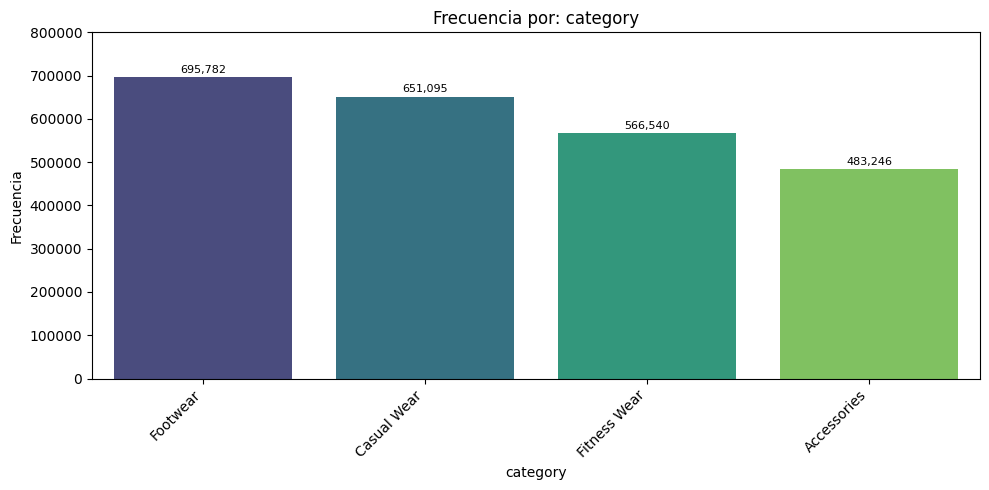

subcategory: Regla del 70% aplicada, se muestran 8 valores y el resto se agrupa en "Otras".


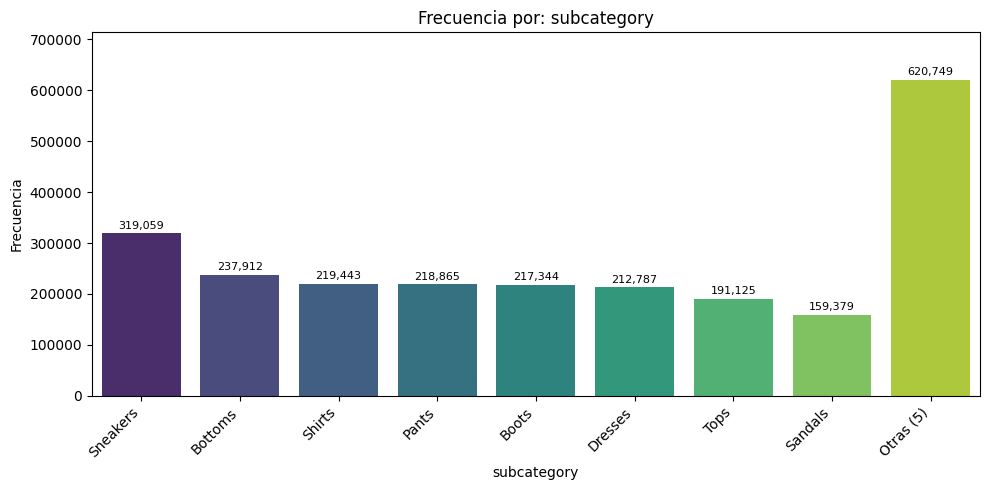

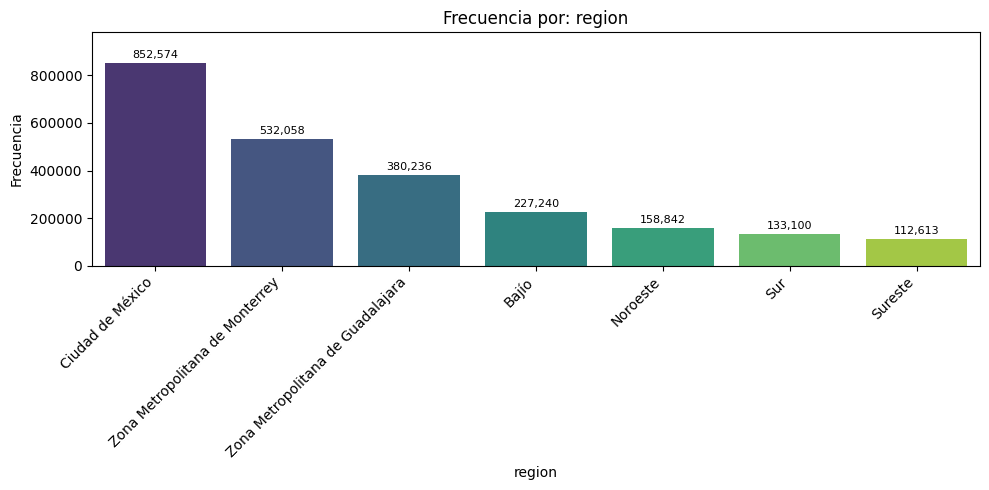

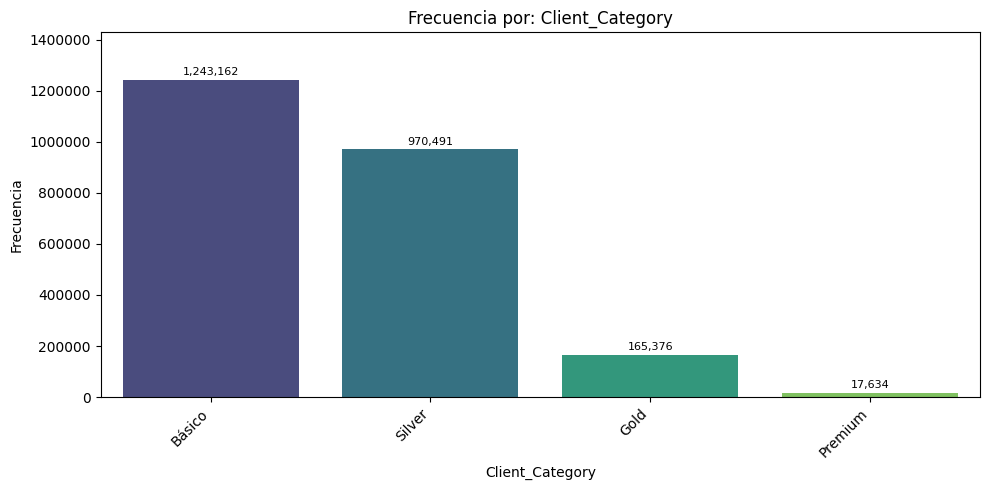

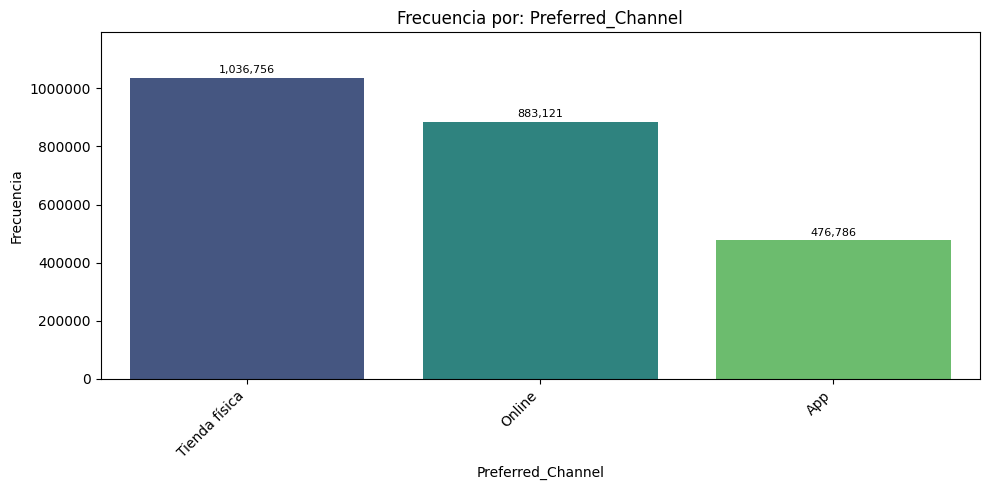

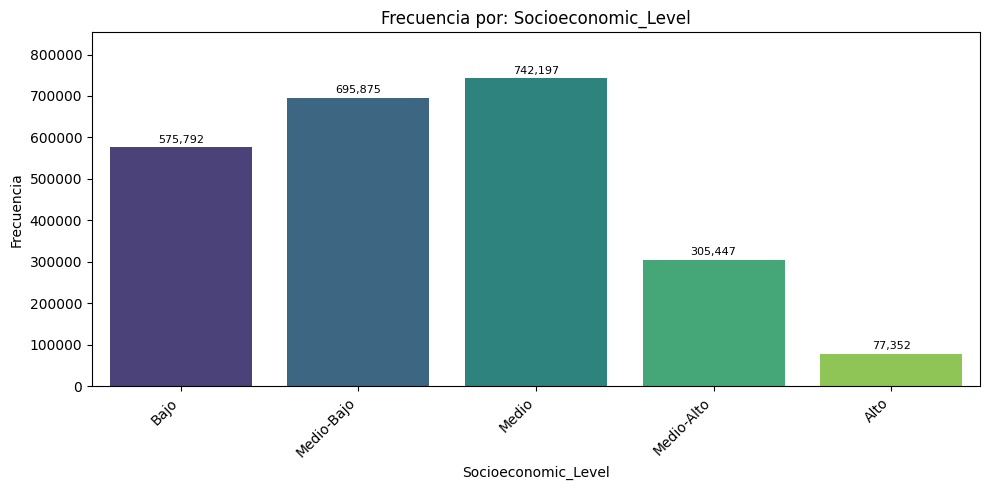

In [ ]:
orden_categorias = {
    'Client_Category': ['Básico', 'Silver', 'Gold', 'Premium'],
    'Socioeconomic_Level': ['Bajo', 'Medio-Bajo', 'Medio', 'Medio-Alto', 'Alto']}

grafica_frecuencia(data_DanuStore_Diario, variables_cualitativas, Orden=orden_categorias)

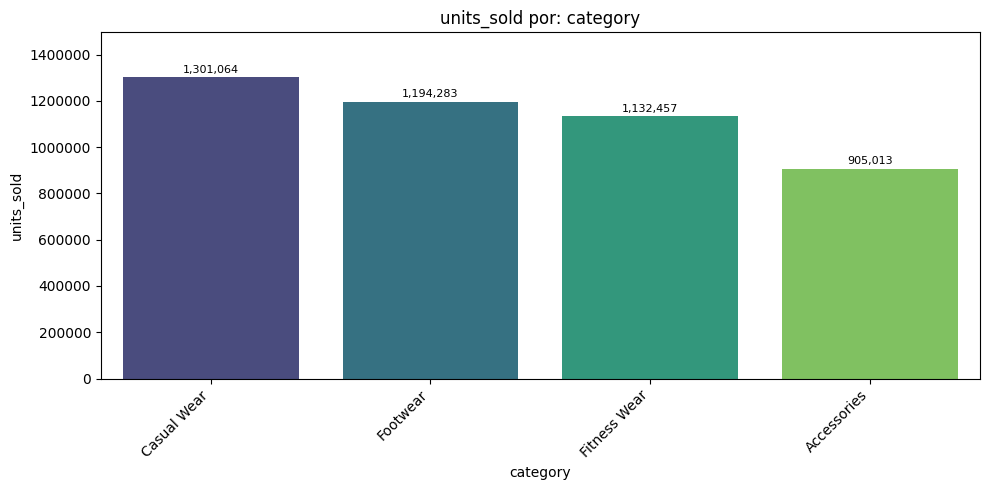

subcategory: Regla del 70% aplicada, se muestran 8 valores y el resto se agrupa en "Otras".


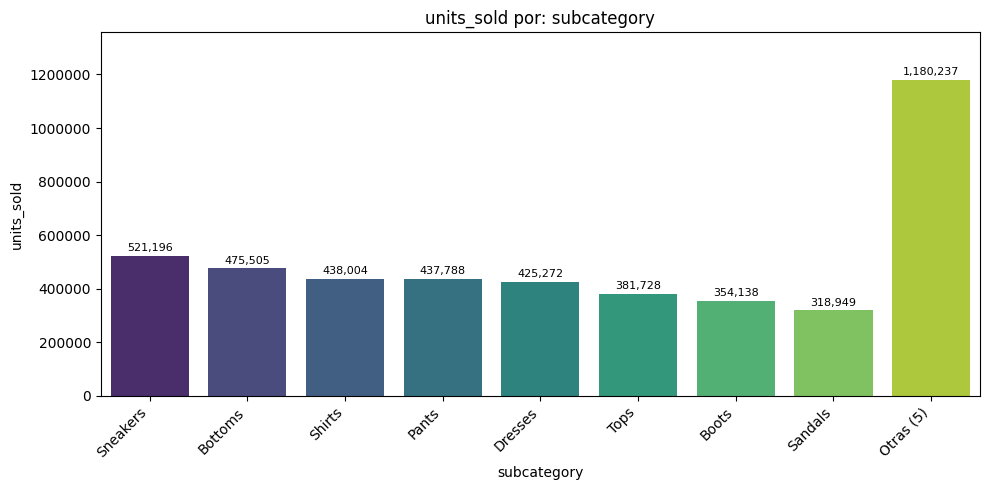

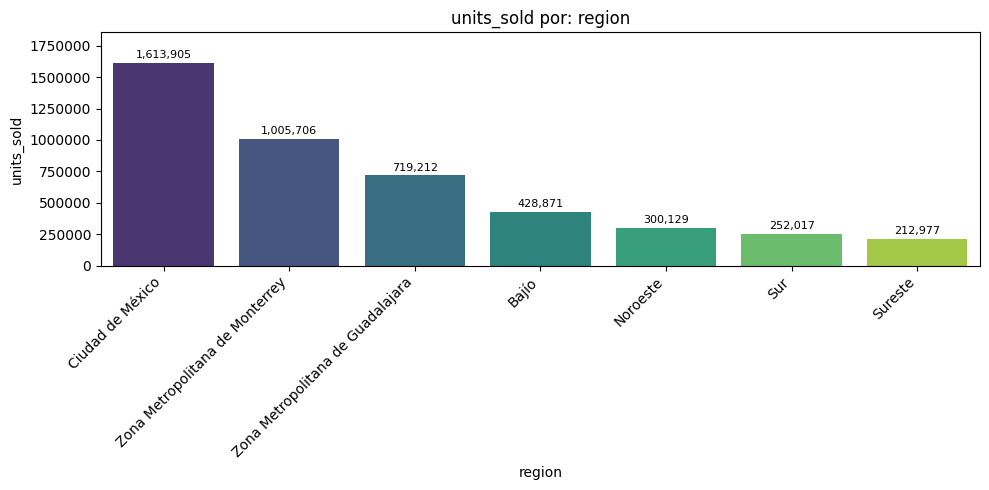

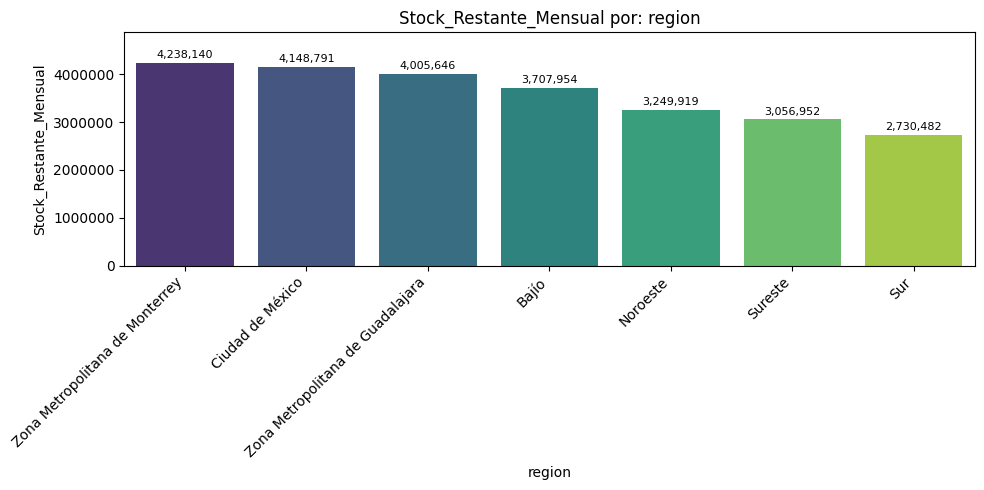

In [ ]:
variables_cualitativas_macro = ['category', 'subcategory', 'region']

grafica_frecuencia(data_DanuStore_Mensual, variables_cualitativas_macro, Peso='units_sold')
grafica_frecuencia(data_DanuStore_Mensual, ['region'], Peso='Stock_Restante_Mensual')

## IV. Variables Cuantitativas

### 4.1 Estadística Descriptiva Básica

In [ ]:
variables_cuantitativas = variables_cuantitativas_discretas + variables_cuantitativas_continuas

print('Nivel Micro (Diario)')
display(data_DanuStore_Diario[[i for i in variables_cuantitativas if i in data_DanuStore_Diario]].describe())

print('')

print('Nivel Macro (Mensual)')
display(data_DanuStore_Mensual[[i for i in variables_cuantitativas if i in data_DanuStore_Mensual]].describe())

Nivel Micro (Diario)


,units_sold,Annual_Purchase_Frequency,sales_amount,Annual_Total_Spend,Cumplimiento_Venta_Esperada
count,2396663.00,2396663.00,2396663.00,2396663.00,2396663.00
mean,1.89,5.91,132.20,10871.76,22.66
std,0.89,3.48,88.84,12195.31,10.69
min,1.00,1.00,13.70,150.00,2.75
25%,1.00,3.00,67.05,2654.40,13.51
50%,2.00,5.00,109.66,6718.08,22.04
75%,2.00,8.00,173.80,14675.08,31.21
max,6.00,26.00,1033.92,118710.24,57.81



Nivel Macro (Mensual)


,units_sold,sales_amount,Cumplimiento_Venta_Esperada,Dias_Cobertura_Inventario
count,21840.00,21840.00,21840.00,21840.00
mean,207.55,14506.75,15.69,289.35
std,175.59,15594.18,9.64,152.04
min,15.00,381.31,2.75,36.20
25%,81.00,4646.08,8.11,165.30
50%,138.50,9011.64,12.01,266.59
75%,286.00,18507.54,21.25,383.27
max,1240.00,153470.47,57.81,1377.41


### 4.2. Variables Cuantitativas Discretas

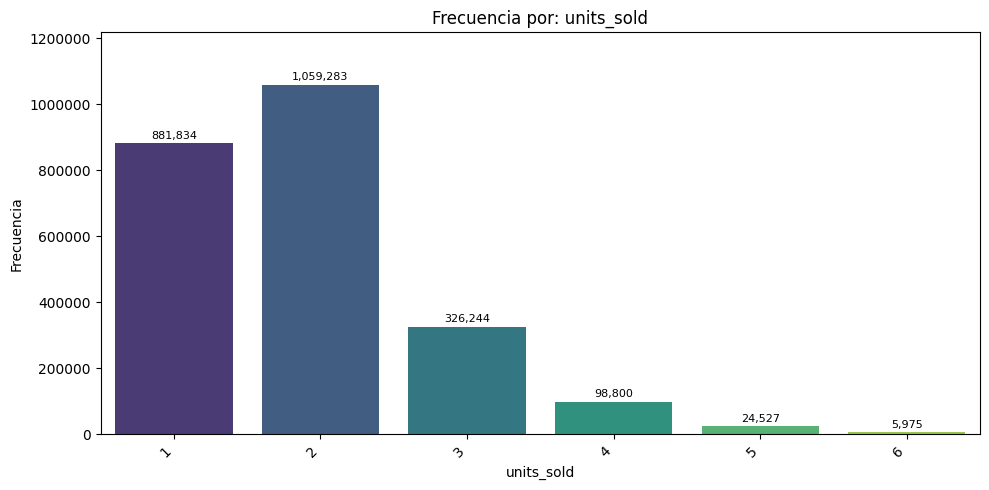

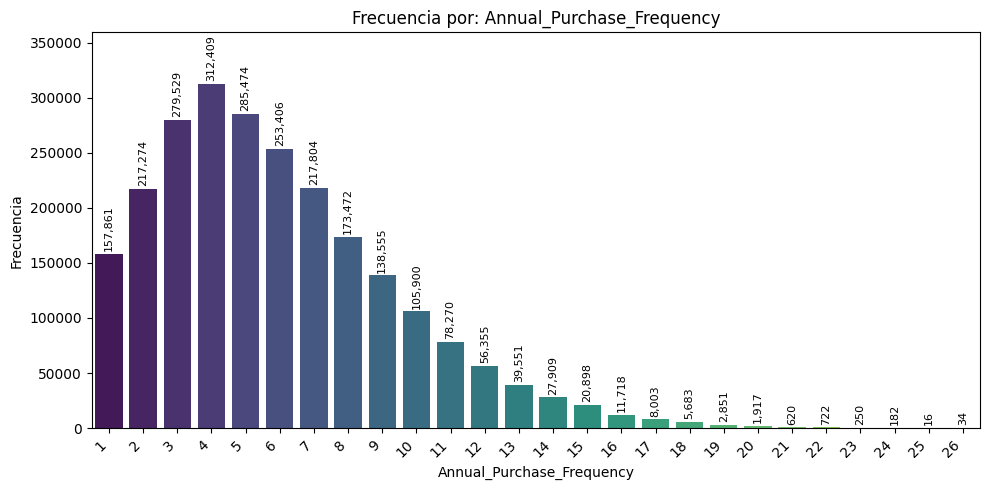

In [ ]:
grafica_frecuencia(data_DanuStore_Diario, variables_cuantitativas_discretas, Ordenar_Valor= True)

### 4.3 Histogramas

In [ ]:
from scipy.stats import norm

def analisis_histograma(DataFrame, Columnas, k_sigma = 3.5, Bins='sturges'):
  for i in Columnas:
    data = DataFrame[i]
    mean = data.mean()
    std = data.std()

    limite_inferior = mean - k_sigma * std
    limite_superior = mean + k_sigma * std

    atipicos = ((data < limite_inferior) | (data > limite_superior)).sum()

    plt.figure(figsize=(10,6))
    sns.histplot(data, bins=Bins, stat='density', color='blue', alpha = 0.5)

    plt.axvline(mean, color='red', linestyle='dashed', linewidth=1.5, label=f'Media: {mean:.2f}')
    plt.axvline(mean + std, color='blue', linestyle='dashed', linewidth=1.5, label=f'Límite Superior (1σ): {mean + std:.2f}')
    plt.axvline(mean - std, color='blue', linestyle='dashed', linewidth=1.5, label=f'Límite Inferior (1σ): {mean - std:.2f}')
    plt.axvline(limite_superior, color='green', linestyle='dotted', linewidth=1.5, label=f'Límite Superior ({k_sigma}σ): {limite_superior:.2f}')
    plt.axvline(limite_inferior, color='green', linestyle='dotted', linewidth=1.5, label=f'Límite Inferior ({k_sigma}σ): {limite_inferior:.2f}')

    xmin, xmax = plt.xlim()
    x = np.linspace(xmin, xmax, 200)
    plt.plot(x, norm.pdf(x, mean, std), 'k', linewidth=2, label=f'Distribución Normal (μ={mean:.2f}, σ={std:.2f})')

    plt.title(f'Histograma de Variable: {i}')
    plt.xlabel(i)
    plt.ylabel('Densidad')
    plt.legend(fontsize=8)
    plt.show()

    print(f'{i}: μ = {mean:,.2f} | σ = {std:,.2f} | Valores fuera de ±{k_sigma}σ: {atipicos:,} ({atipicos / len(data) * 100:.2f}%)')
    print('')
    print('---------------------------------------------------------------------')
    print('')

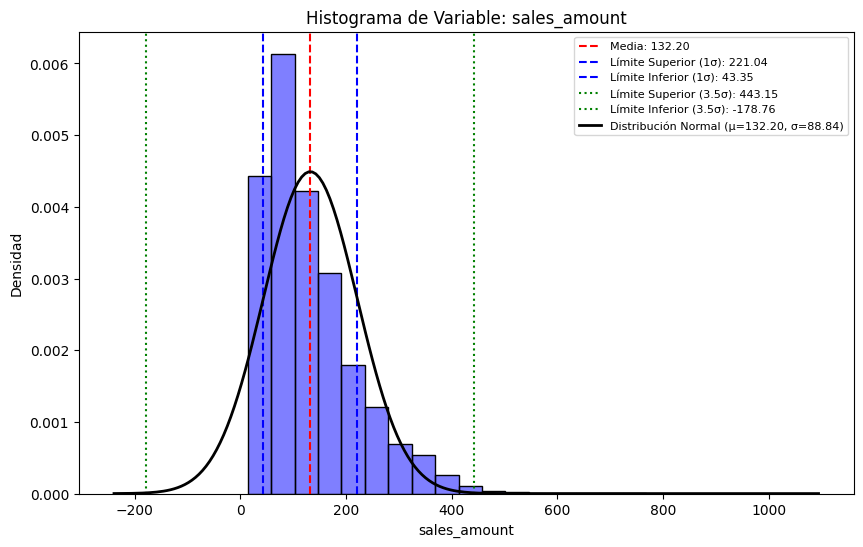

sales_amount: μ = 132.19524152540427 | σ = 88.84360829357543 | Valores fuera de ±3.5σ: 12,002 (0.50%)


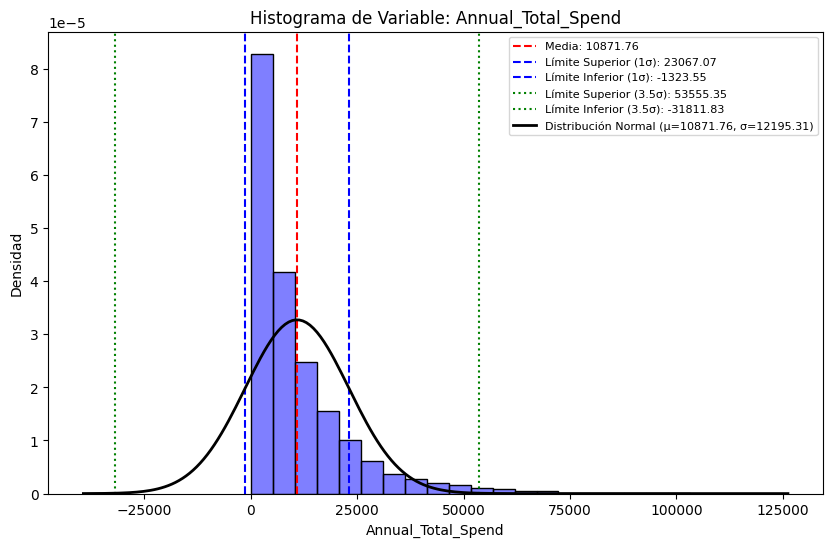

Annual_Total_Spend: μ = 10871.759285222835 | σ = 12195.31122971179 | Valores fuera de ±3.5σ: 34,833 (1.45%)


In [ ]:
analisis_histograma(data_DanuStore_Diario, ['sales_amount', 'Annual_Total_Spend'])

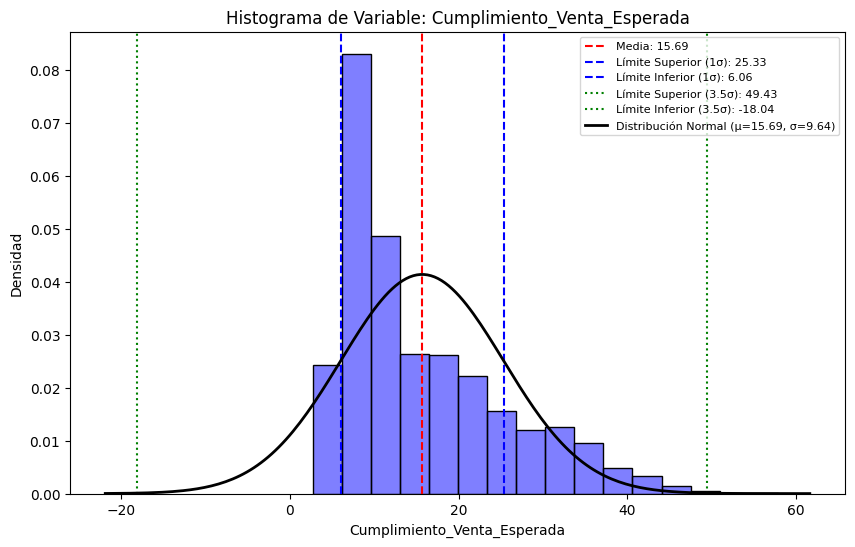

Cumplimiento_Venta_Esperada: μ = 15.694207875457876 | σ = 9.639192378180363 | Valores fuera de ±3.5σ: 22 (0.10%)


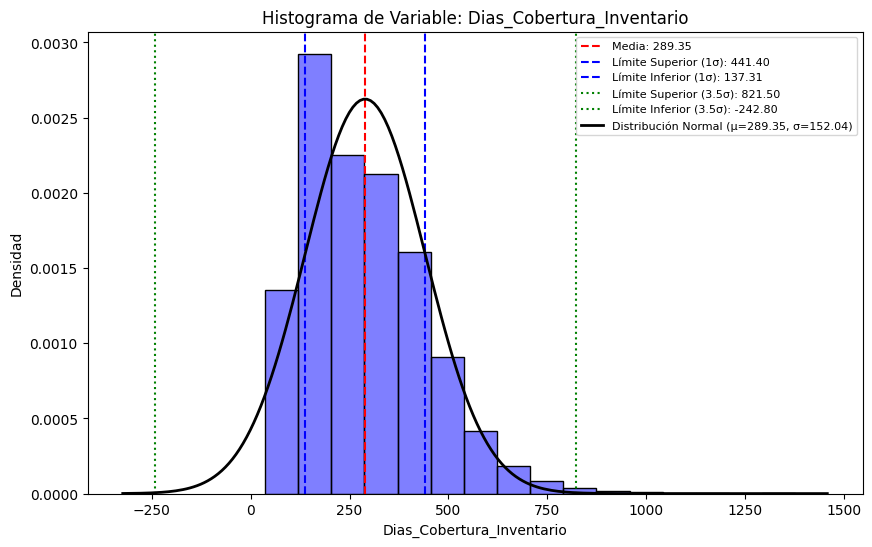

Dias_Cobertura_Inventario: μ = 289.35222161172163 | σ = 152.0435622722811 | Valores fuera de ±3.5σ: 93 (0.43%)


In [ ]:
analisis_histograma(data_DanuStore_Mensual, ['Cumplimiento_Venta_Esperada', 'Dias_Cobertura_Inventario'])

### 4.4 Boxplots para Variables Cuantitativas

Se grafican todas las variables cuantitativas en ambos niveles de detalle Micro y Macro. También, se usa escala logarítmica cuando la variable presenta un sesgo fuerte (asimetría > 2), y se reportan los atípicos extremos, usando un rango de 3 IQRs.

In [ ]:
def analisis_boxplot(DataFrame, Columnas):
  for i in Columnas:
    data = DataFrame[i]
    q1 = data.quantile(0.25)
    q3 = data.quantile(0.75)
    iqr = q3 - q1
    bigotes = ((data < q1 - 3 * iqr) | (data > q3 + 3 * iqr)).sum()
    logaritmica = data.skew() > 2 and data.min() > 0

    plt.figure(figsize = (10, 2.5))
    sns.boxplot(x = data, color = 'skyblue', flierprops={'marker': '.', 'markersize': 2, 'alpha': 0.3})

    if logaritmica:
      plt.xscale('log')

    plt.title(f'Boxplot de Variable: {i}' + (' (escala logarítmica)' if logaritmica else ''))
    plt.xlabel(i)
    plt.tight_layout()
    plt.show()

    print(f'{i}: Atípicos extremos (> 3 IQR): {bigotes:,} ({bigotes / len(data) * 100:.2f}%)\n')


Se utiliza tolist() para, en este caso, usar todas las variables cuantitativas de ambos dataframes, en ambos niveles de detalle. Se excluyen las variables de fecha (date y year), pues son variables de calendario, y realmente no aportan mucho a este tipo de análisis.

In [ ]:
cuantitativas_macro = data_DanuStore_Mensual.select_dtypes(include='number').columns.drop(['year']).tolist()
cuantitativas_micro = data_DanuStore_Diario.select_dtypes(include='number').columns.drop(['day', 'year']).tolist()

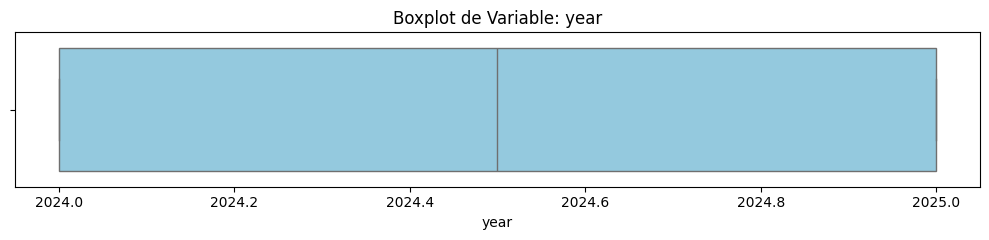

year: Atípicos extremos (> 3 IQR): 0 (0.00%)



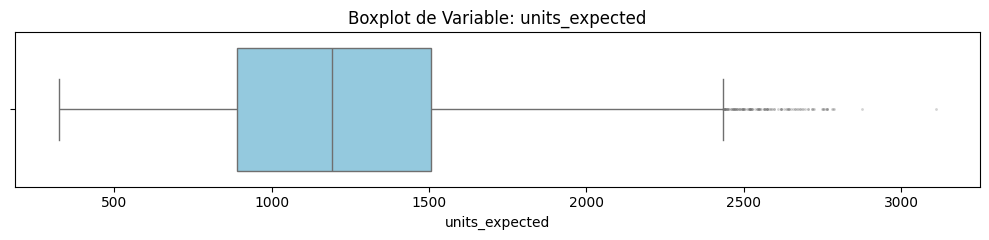

units_expected: Atípicos extremos (> 3 IQR): 0 (0.00%)



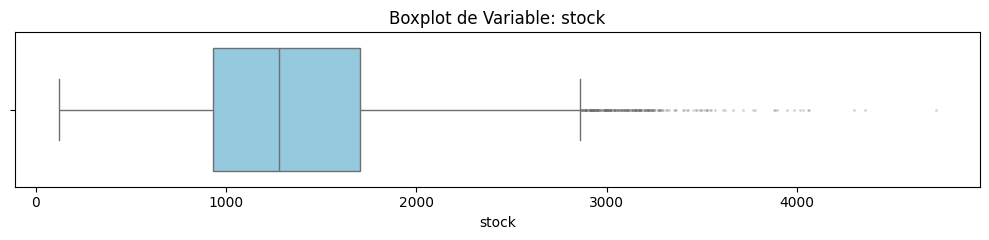

stock: Atípicos extremos (> 3 IQR): 6 (0.03%)



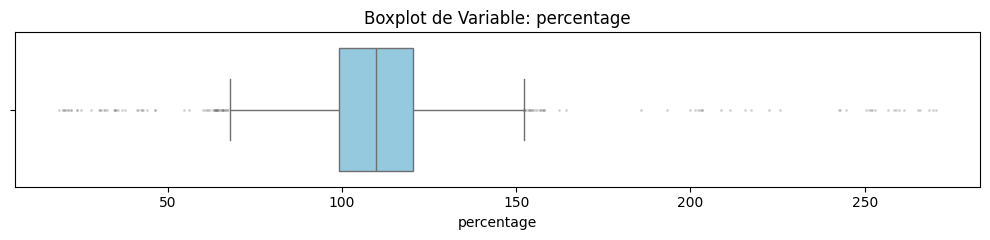

percentage: Atípicos extremos (> 3 IQR): 55 (0.25%)



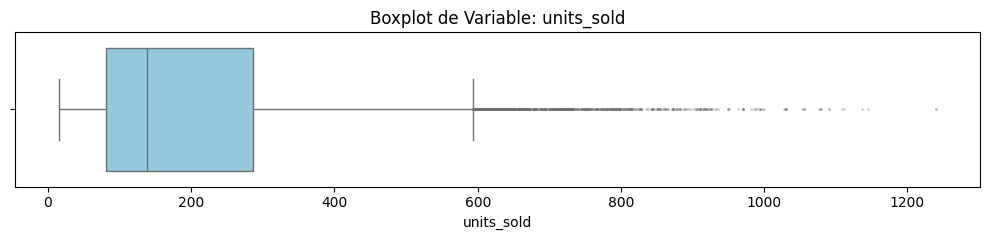

units_sold: Atípicos extremos (> 3 IQR): 75 (0.34%)



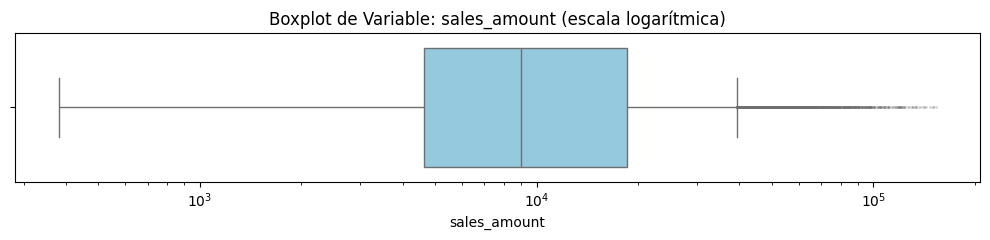

sales_amount: Atípicos extremos (> 3 IQR): 504 (2.31%)



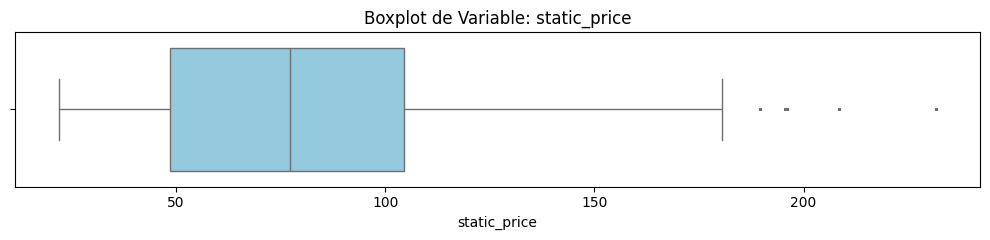

static_price: Atípicos extremos (> 3 IQR): 0 (0.00%)



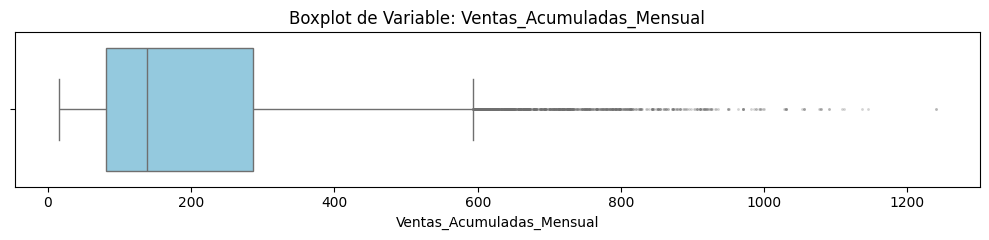

Ventas_Acumuladas_Mensual: Atípicos extremos (> 3 IQR): 75 (0.34%)



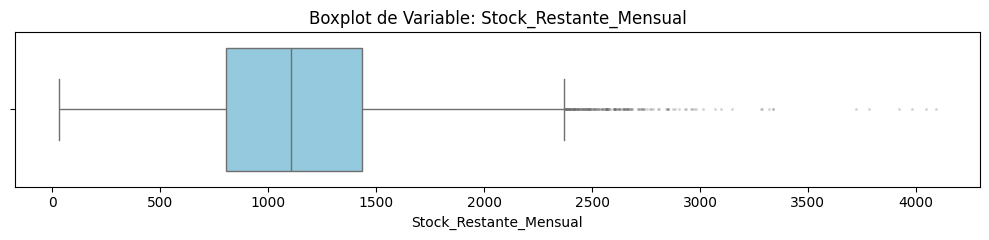

Stock_Restante_Mensual: Atípicos extremos (> 3 IQR): 9 (0.04%)



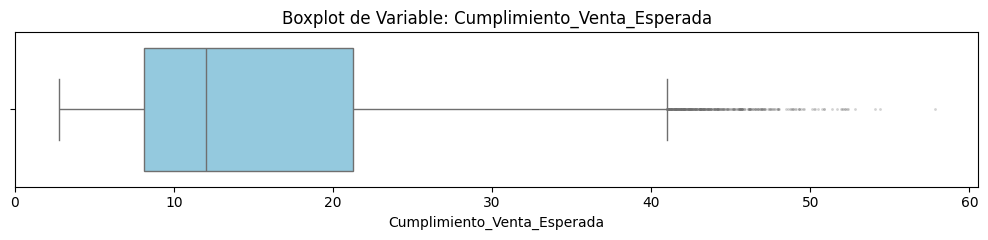

Cumplimiento_Venta_Esperada: Atípicos extremos (> 3 IQR): 0 (0.00%)



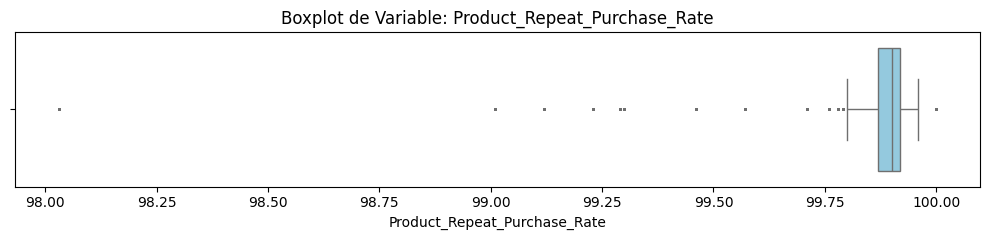

Product_Repeat_Purchase_Rate: Atípicos extremos (> 3 IQR): 1,512 (6.92%)



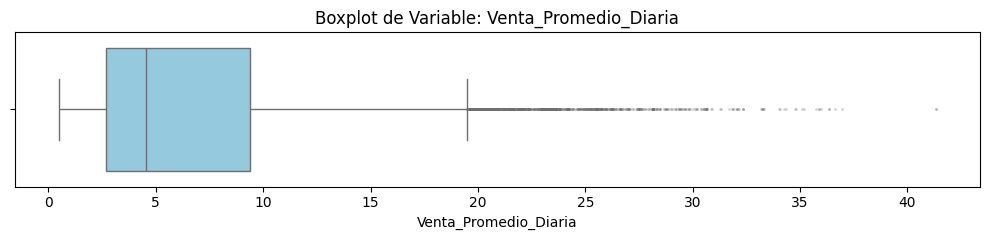

Venta_Promedio_Diaria: Atípicos extremos (> 3 IQR): 67 (0.31%)



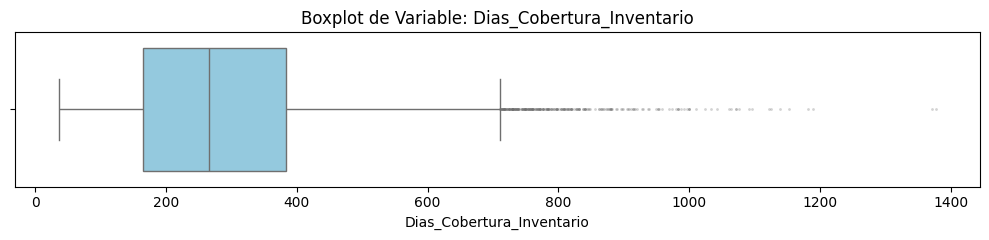

Dias_Cobertura_Inventario: Atípicos extremos (> 3 IQR): 16 (0.07%)



In [ ]:
analisis_boxplot(data_DanuStore_Mensual, cuantitativas_macro)

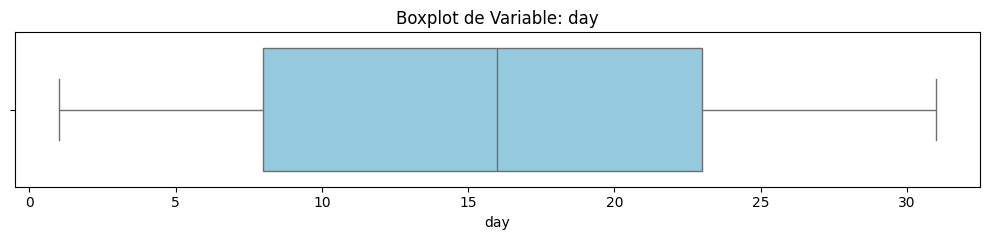

day: Atípicos extremos (> 3 IQR): 0 (0.00%)



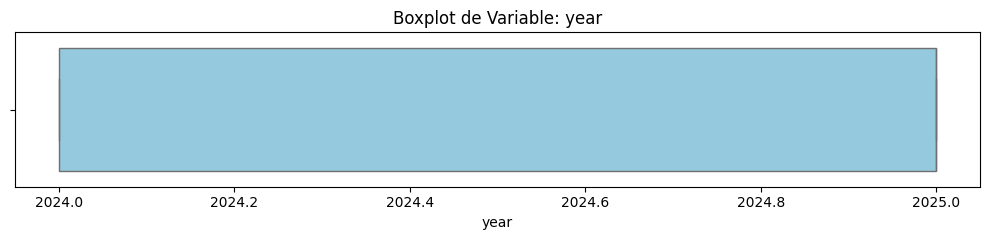

year: Atípicos extremos (> 3 IQR): 0 (0.00%)



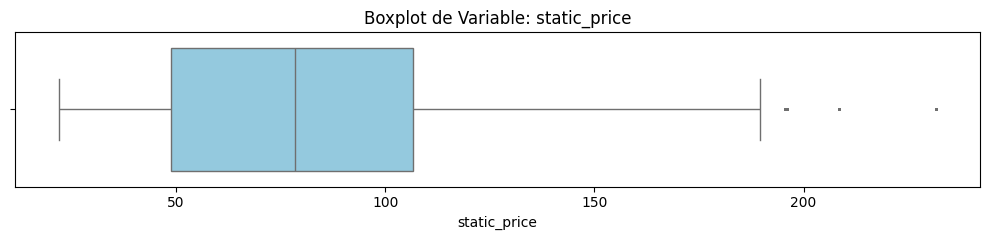

static_price: Atípicos extremos (> 3 IQR): 0 (0.00%)



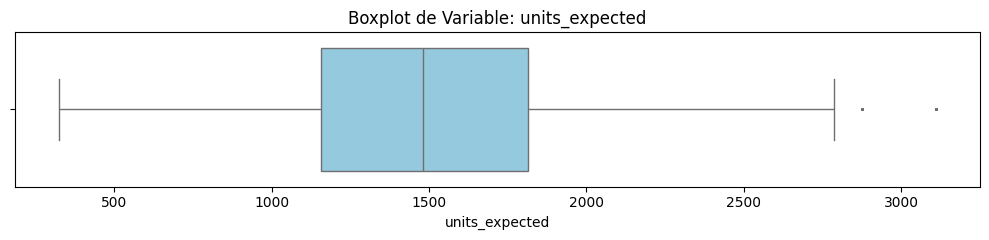

units_expected: Atípicos extremos (> 3 IQR): 0 (0.00%)



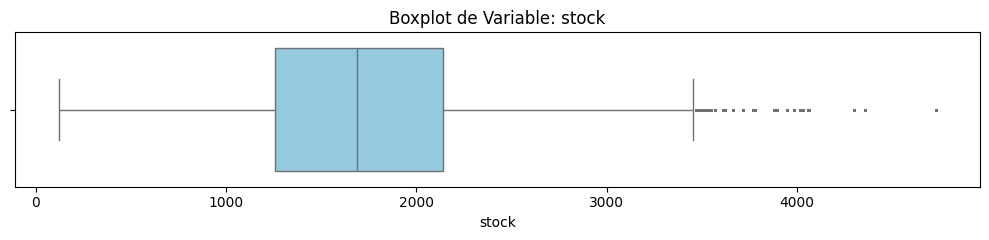

stock: Atípicos extremos (> 3 IQR): 0 (0.00%)



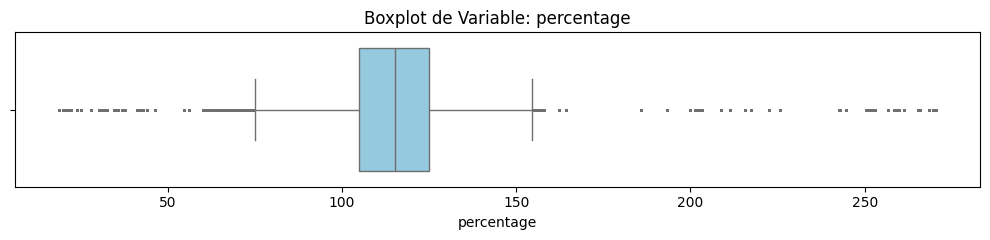

percentage: Atípicos extremos (> 3 IQR): 6,747 (0.28%)



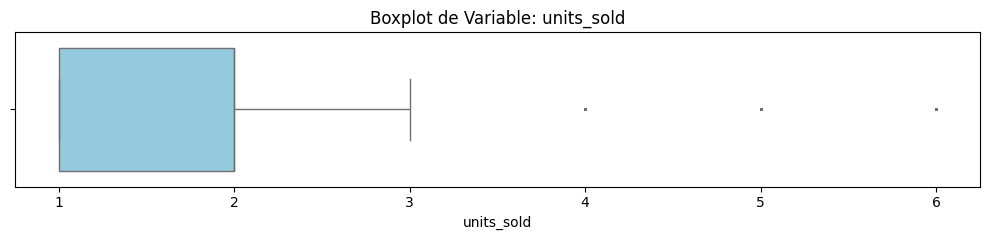

units_sold: Atípicos extremos (> 3 IQR): 5,975 (0.25%)



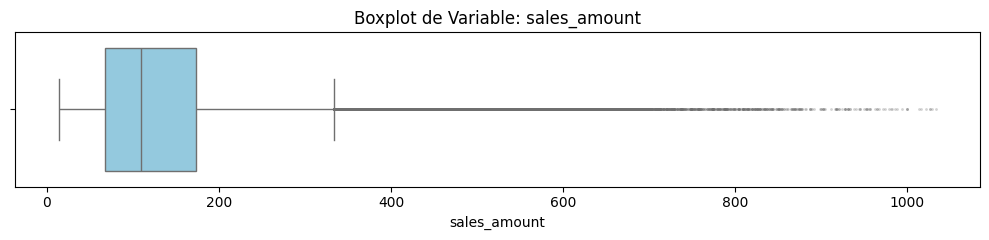

sales_amount: Atípicos extremos (> 3 IQR): 5,906 (0.25%)



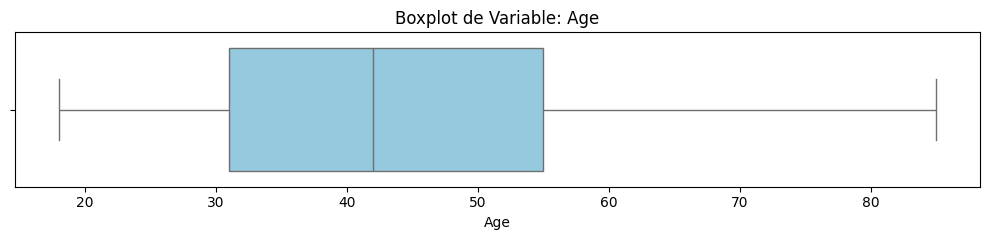

Age: Atípicos extremos (> 3 IQR): 0 (0.00%)



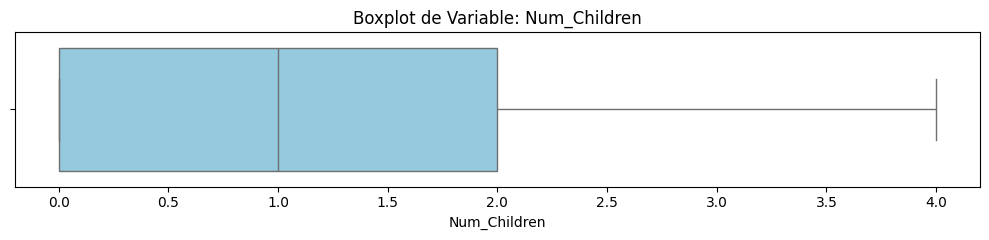

Num_Children: Atípicos extremos (> 3 IQR): 0 (0.00%)



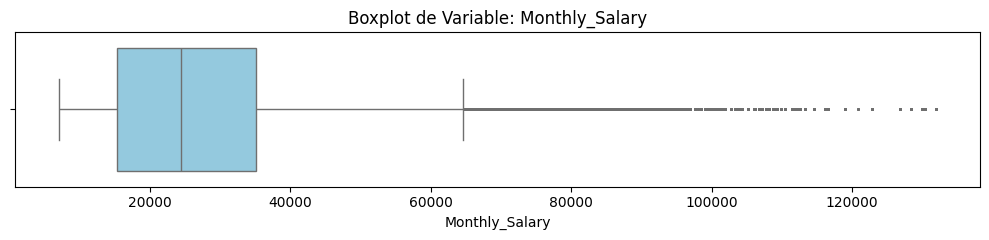

Monthly_Salary: Atípicos extremos (> 3 IQR): 5,082 (0.21%)



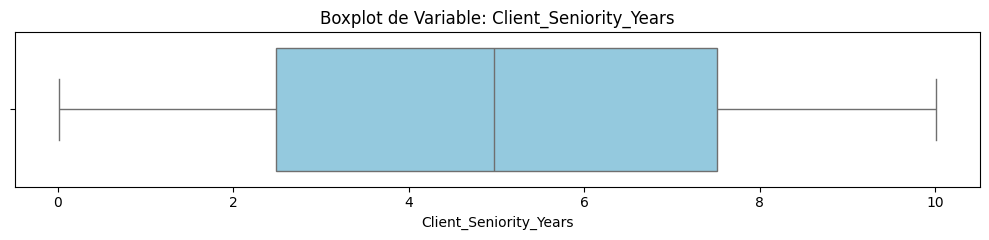

Client_Seniority_Years: Atípicos extremos (> 3 IQR): 0 (0.00%)



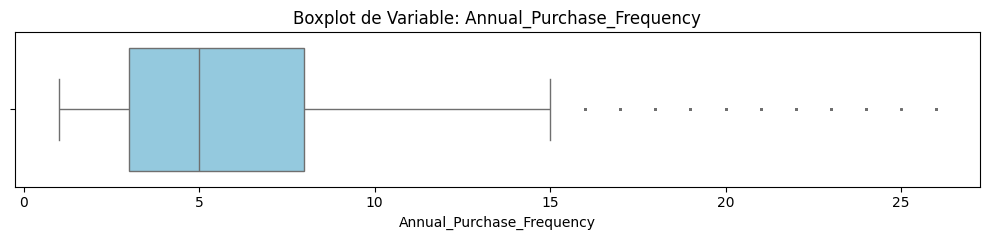

Annual_Purchase_Frequency: Atípicos extremos (> 3 IQR): 232 (0.01%)



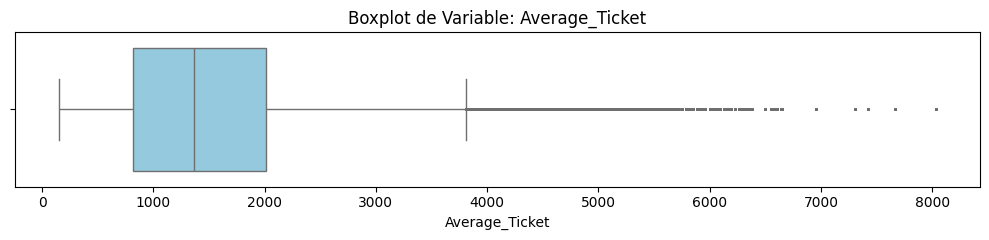

Average_Ticket: Atípicos extremos (> 3 IQR): 3,843 (0.16%)



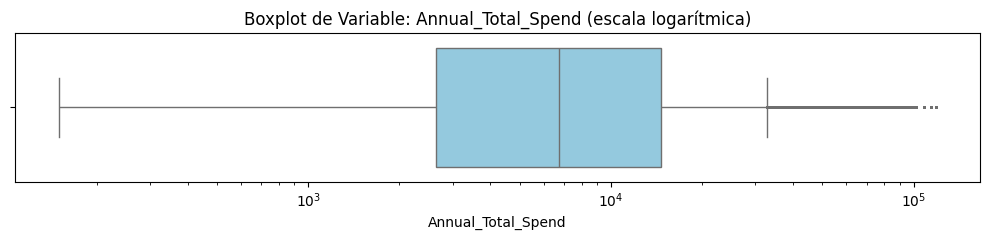

Annual_Total_Spend: Atípicos extremos (> 3 IQR): 43,516 (1.82%)



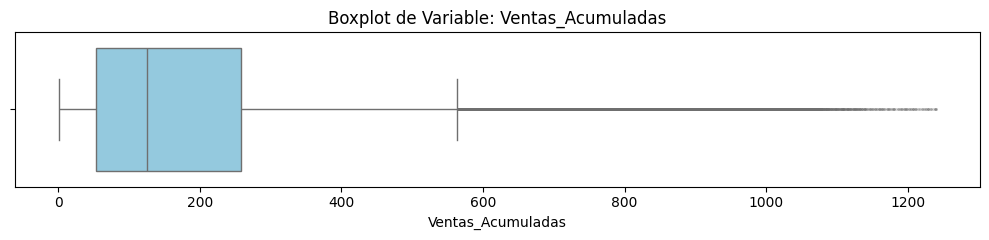

Ventas_Acumuladas: Atípicos extremos (> 3 IQR): 4,378 (0.18%)



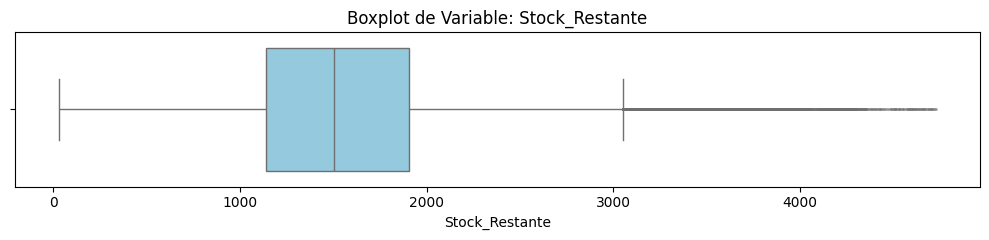

Stock_Restante: Atípicos extremos (> 3 IQR): 381 (0.02%)



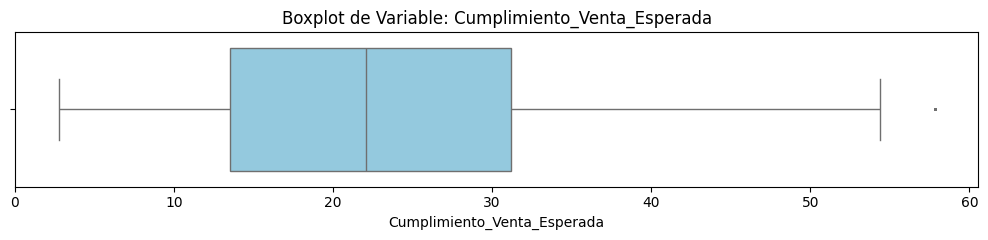

Cumplimiento_Venta_Esperada: Atípicos extremos (> 3 IQR): 0 (0.00%)



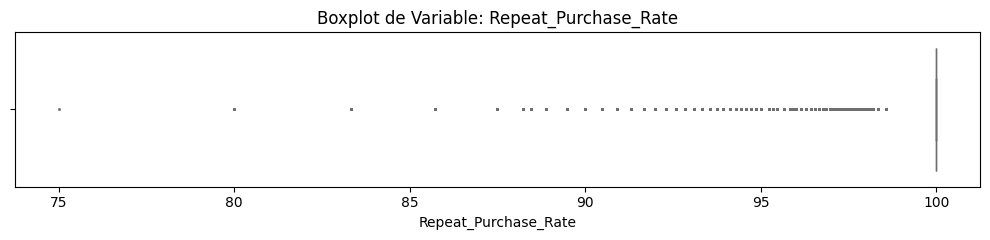

Repeat_Purchase_Rate: Atípicos extremos (> 3 IQR): 151,710 (6.33%)



In [ ]:
analisis_boxplot(data_DanuStore_Diario, cuantitativas_micro)

## V. Análisis de Variables Cuantitativas respecto a Variables Cualitativas

Para cada variable cualitativa, se grafican boxplots de todas las variables cuantitativas de su mismo nivel de detalle. Por otro lado, como se ha estado realizando en el resto del código, en aquellas variables con más de 12 categorías, se conservan las que concentran el **70% de las unidades vendidas** mientras que el resto se agrupa en "Otras".

In [ ]:
def analisis_boxplot_cuanti_cuali(DataFrame, Cualitativas, Cuantitativas, Max_Categorias = 12, Orden ={}, Peso = None):
  for i in Cualitativas:
    data = DataFrame[[i] + Cuantitativas].copy()
    data[i] = data[i].astype(str)

    if Peso:
      freq = DataFrame.groupby(data[i])[Peso].sum().sort_values(ascending = False)
    else:
      freq = data[i].value_counts()

    if len(freq) > Max_Categorias:
      acumulado = freq.cumsum() / freq.sum() * 100
      top = freq[acumulado.shift(fill_value=0) < 70].index.tolist()
      data.loc[~data[i].isin(top), i] = 'Otras'
      orden = top + ['Otras']
      print(f'{i}: Regla del 70% aplicada, se muestran {len(top)} categorías y el resto se agrupa en "Otras".')
    else:
      orden = Orden.get(i, freq.index.tolist())

    total = data.copy()
    total[i] = 'Todos los datos'
    data = pd.concat([data, total], ignore_index=True)
    orden = orden + ['Todos los datos']

    ## Graficación

    fig, axes = plt.subplots(len(Cuantitativas), 1, figsize=(12, 4 * len(Cuantitativas)))
    axes = np.atleast_1d(axes)
    colores = sns.color_palette('viridis', len(orden) - 1) + [(0.7, 0.7, 0.7)]

    for ax, j in zip(axes, Cuantitativas):
      sns.boxplot(data=data, x=i, y=j, order=orden, hue=i, hue_order=orden, palette=colores,
                  legend=False, ax=ax, flierprops={'marker': '.', 'markersize': 2, 'alpha': 0.3})

      if DataFrame[j].skew() > 2 and DataFrame[j].min() > 0:
        ax.set_yscale('log')
        ax.set_title(f'{j} (escala logarítmica)')
      else:
        ax.set_title(j)

      ax.set_xlabel('')
      plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

    fig.suptitle(f'Categorías de {i}', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

### 5.1 Cruce de Variables en Nivel Macro (Mensual)

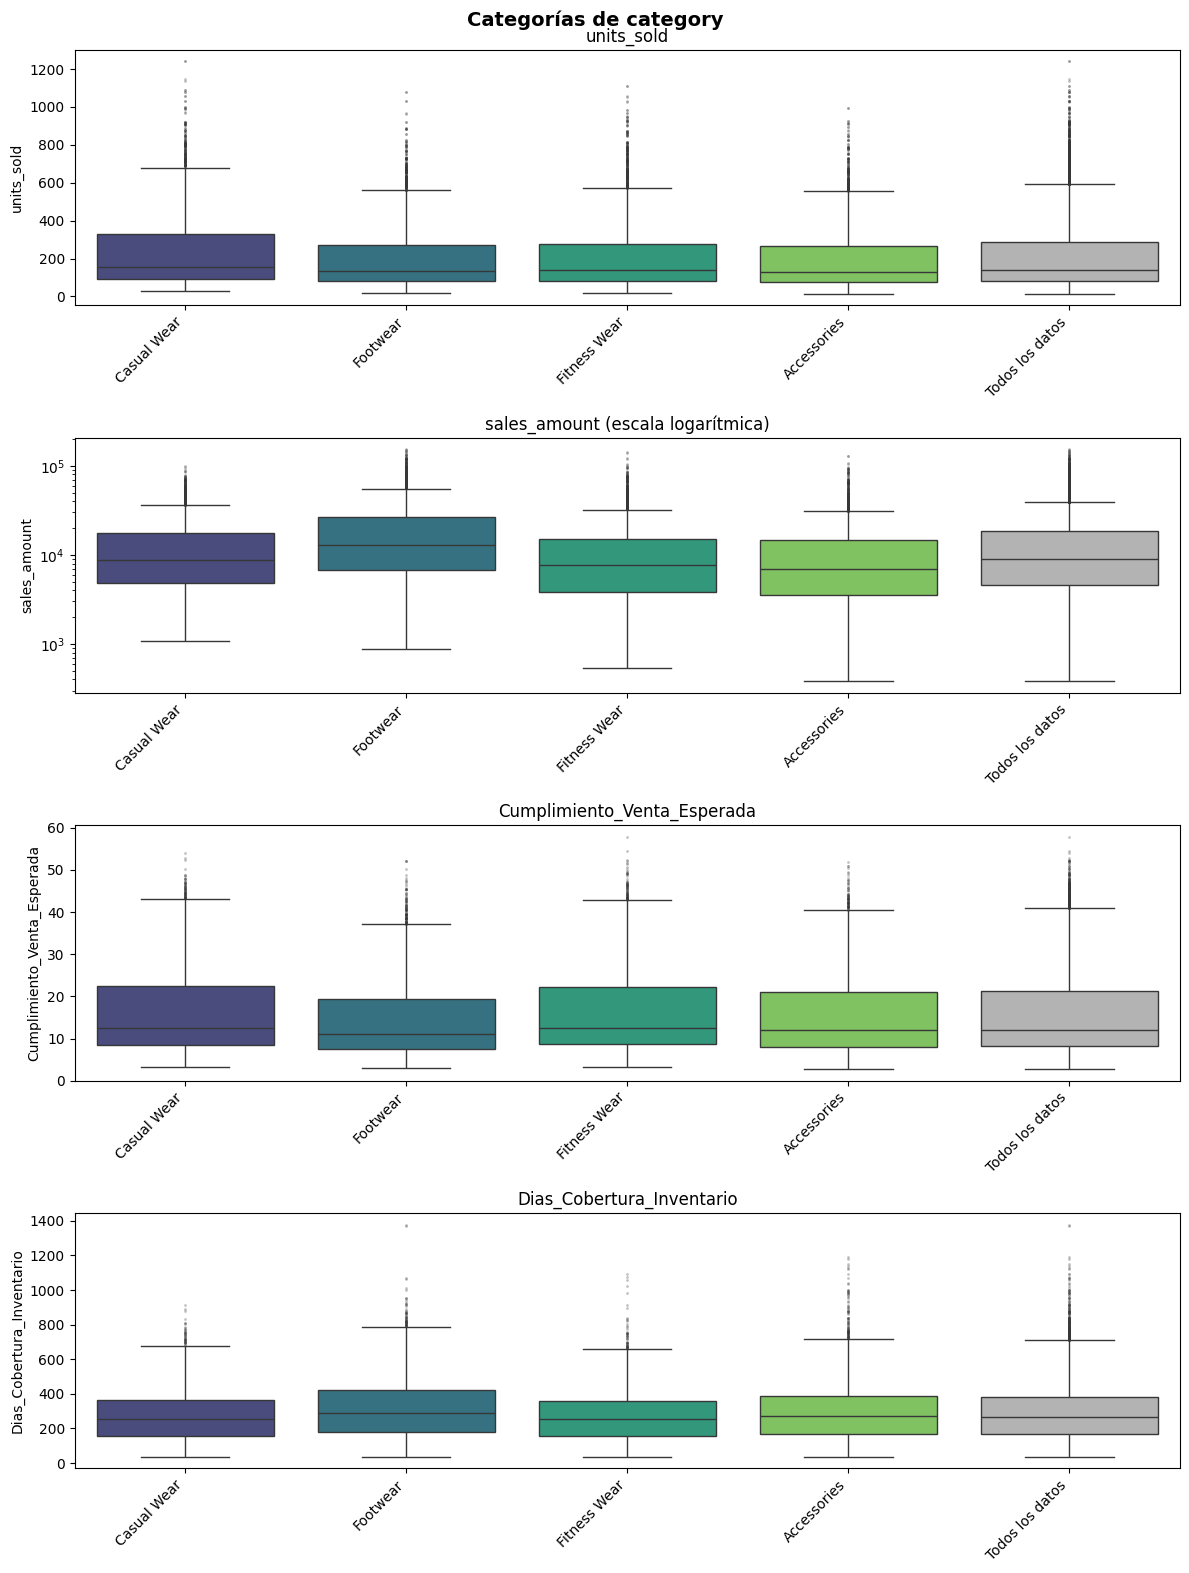

subcategory: Regla del 70% aplicada, se muestran 8 categorías y el resto se agrupa en "Otras".


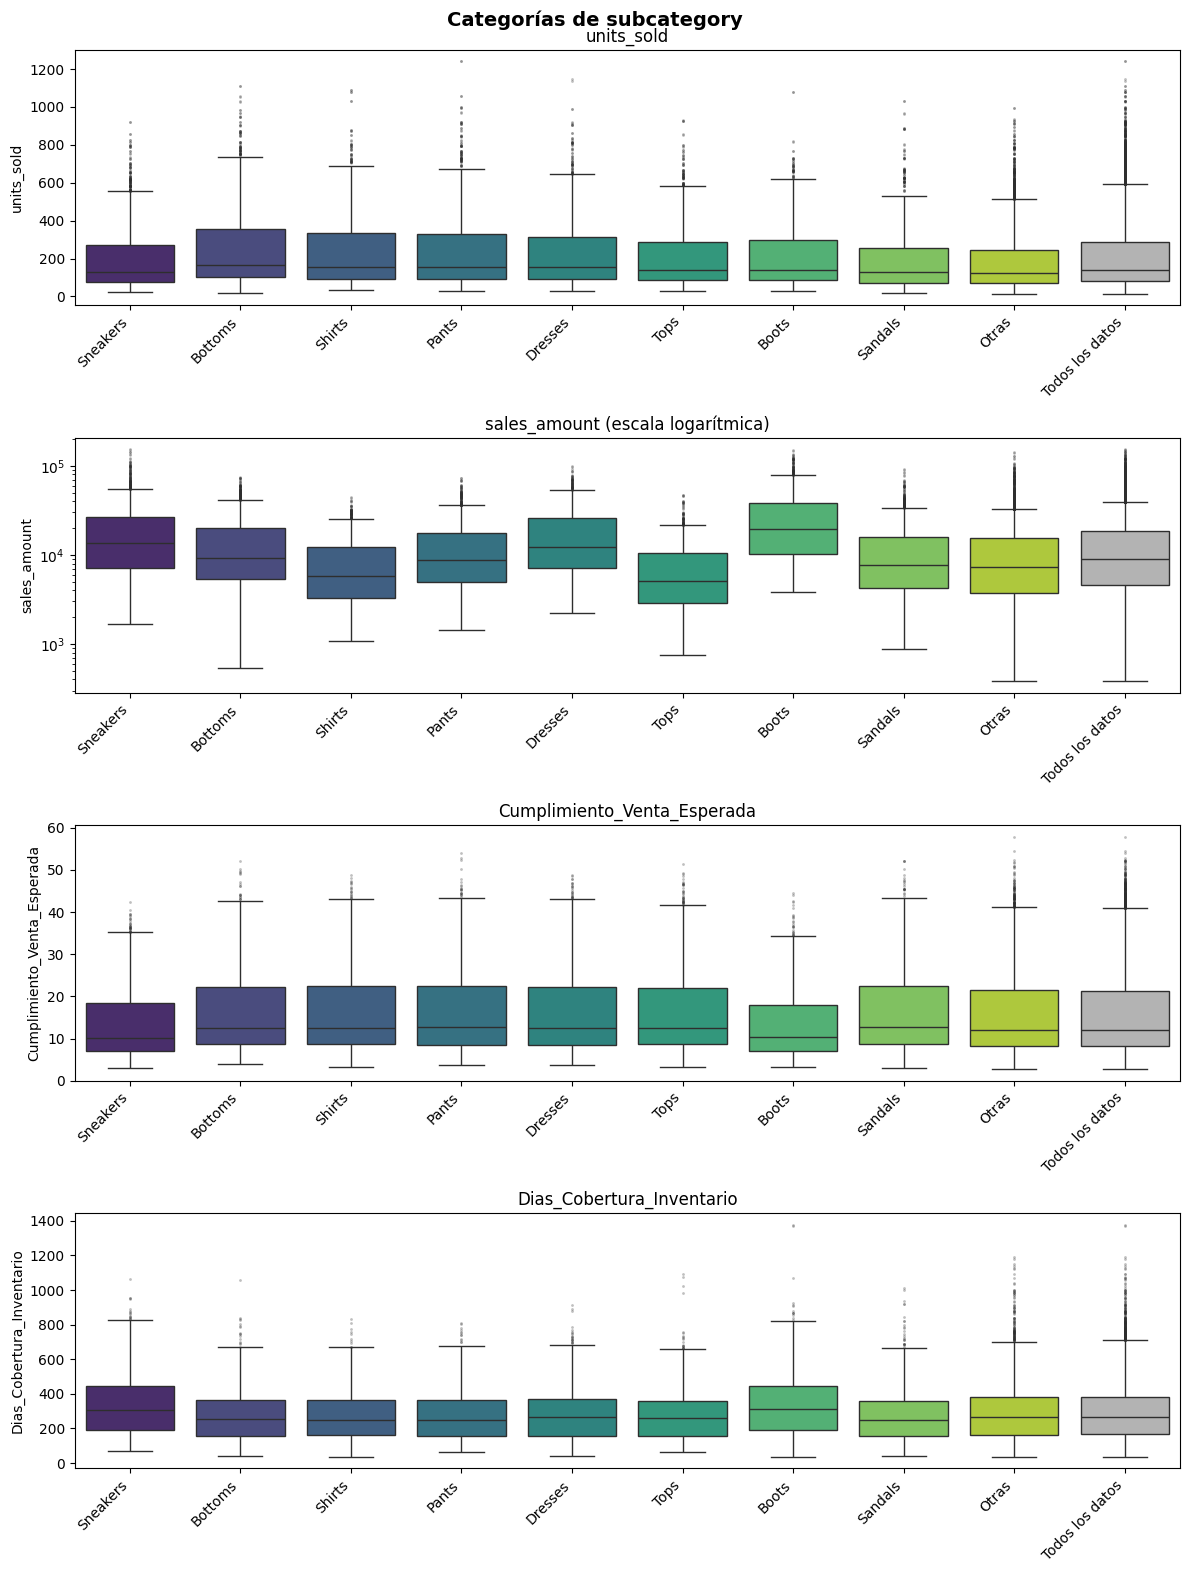

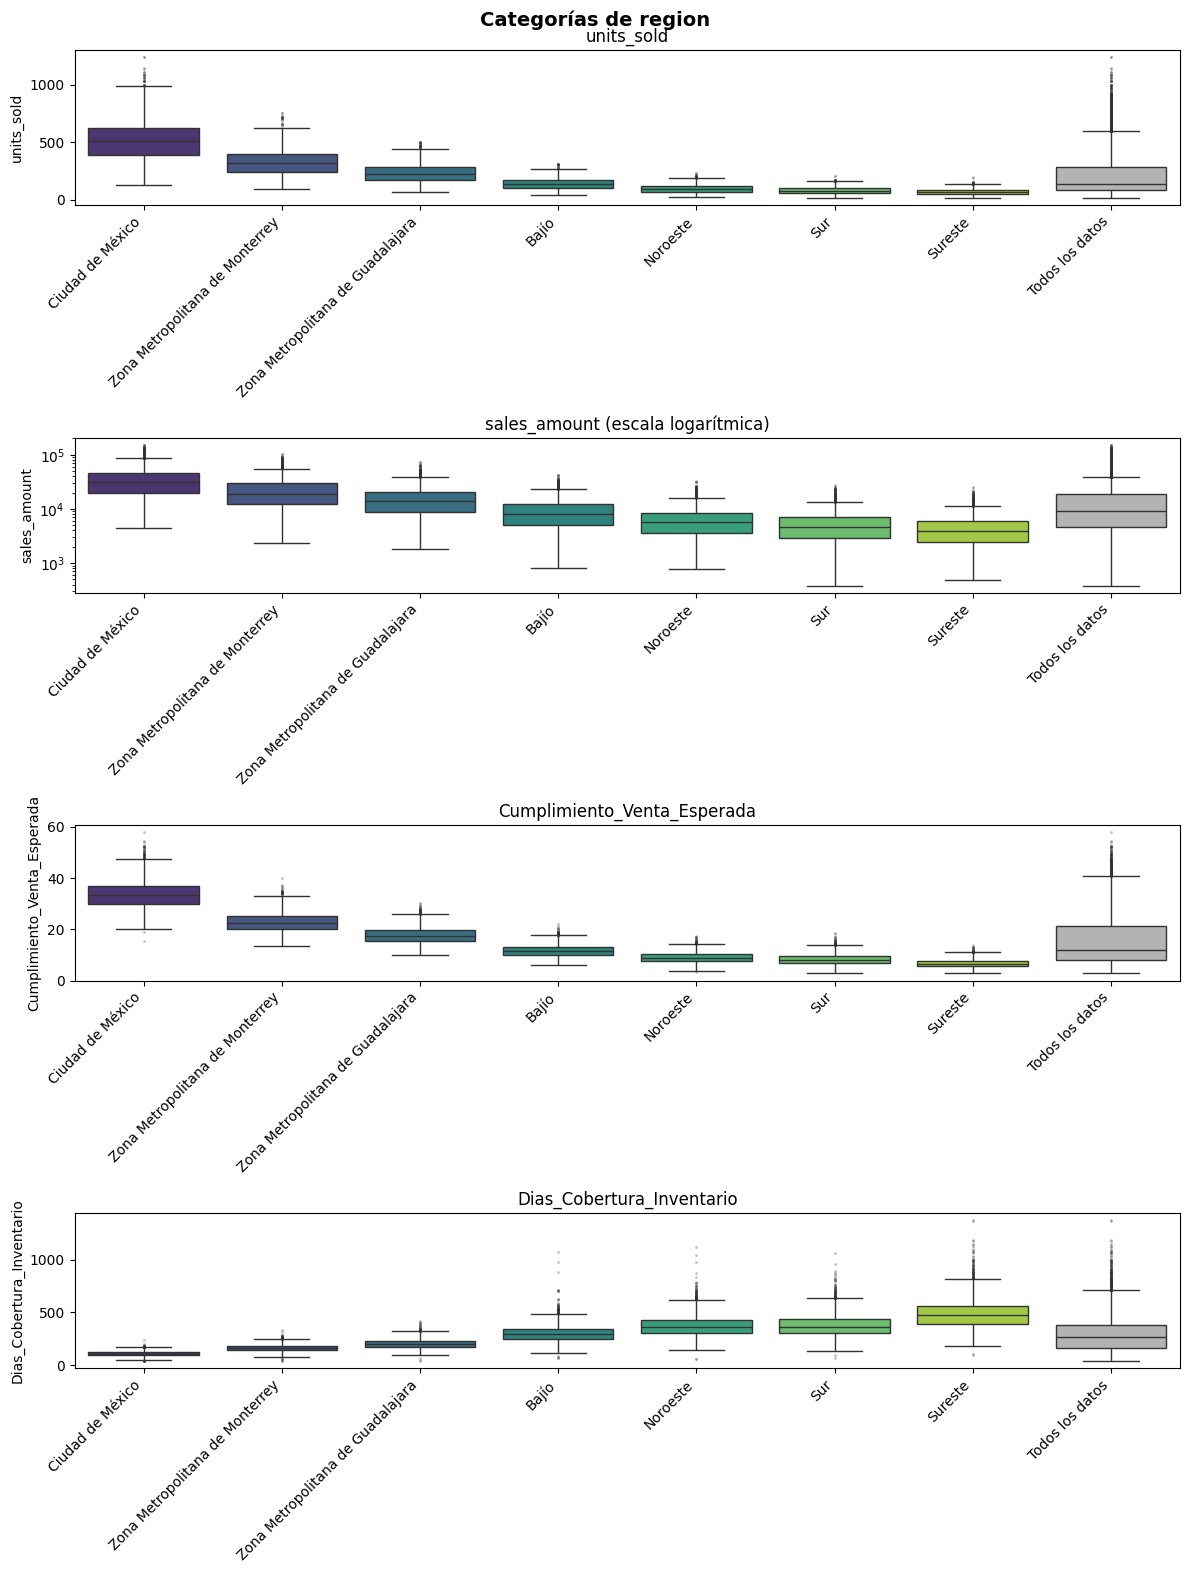

In [ ]:
cuantitativas_cruce_macro = ['units_sold', 'sales_amount', 'Cumplimiento_Venta_Esperada', 'Dias_Cobertura_Inventario']

analisis_boxplot_cuanti_cuali(data_DanuStore_Mensual, variables_cualitativas_macro, cuantitativas_cruce_macro, Peso='units_sold')

### 5.2 Cruce de Variables en Nivel Micro (Diario)

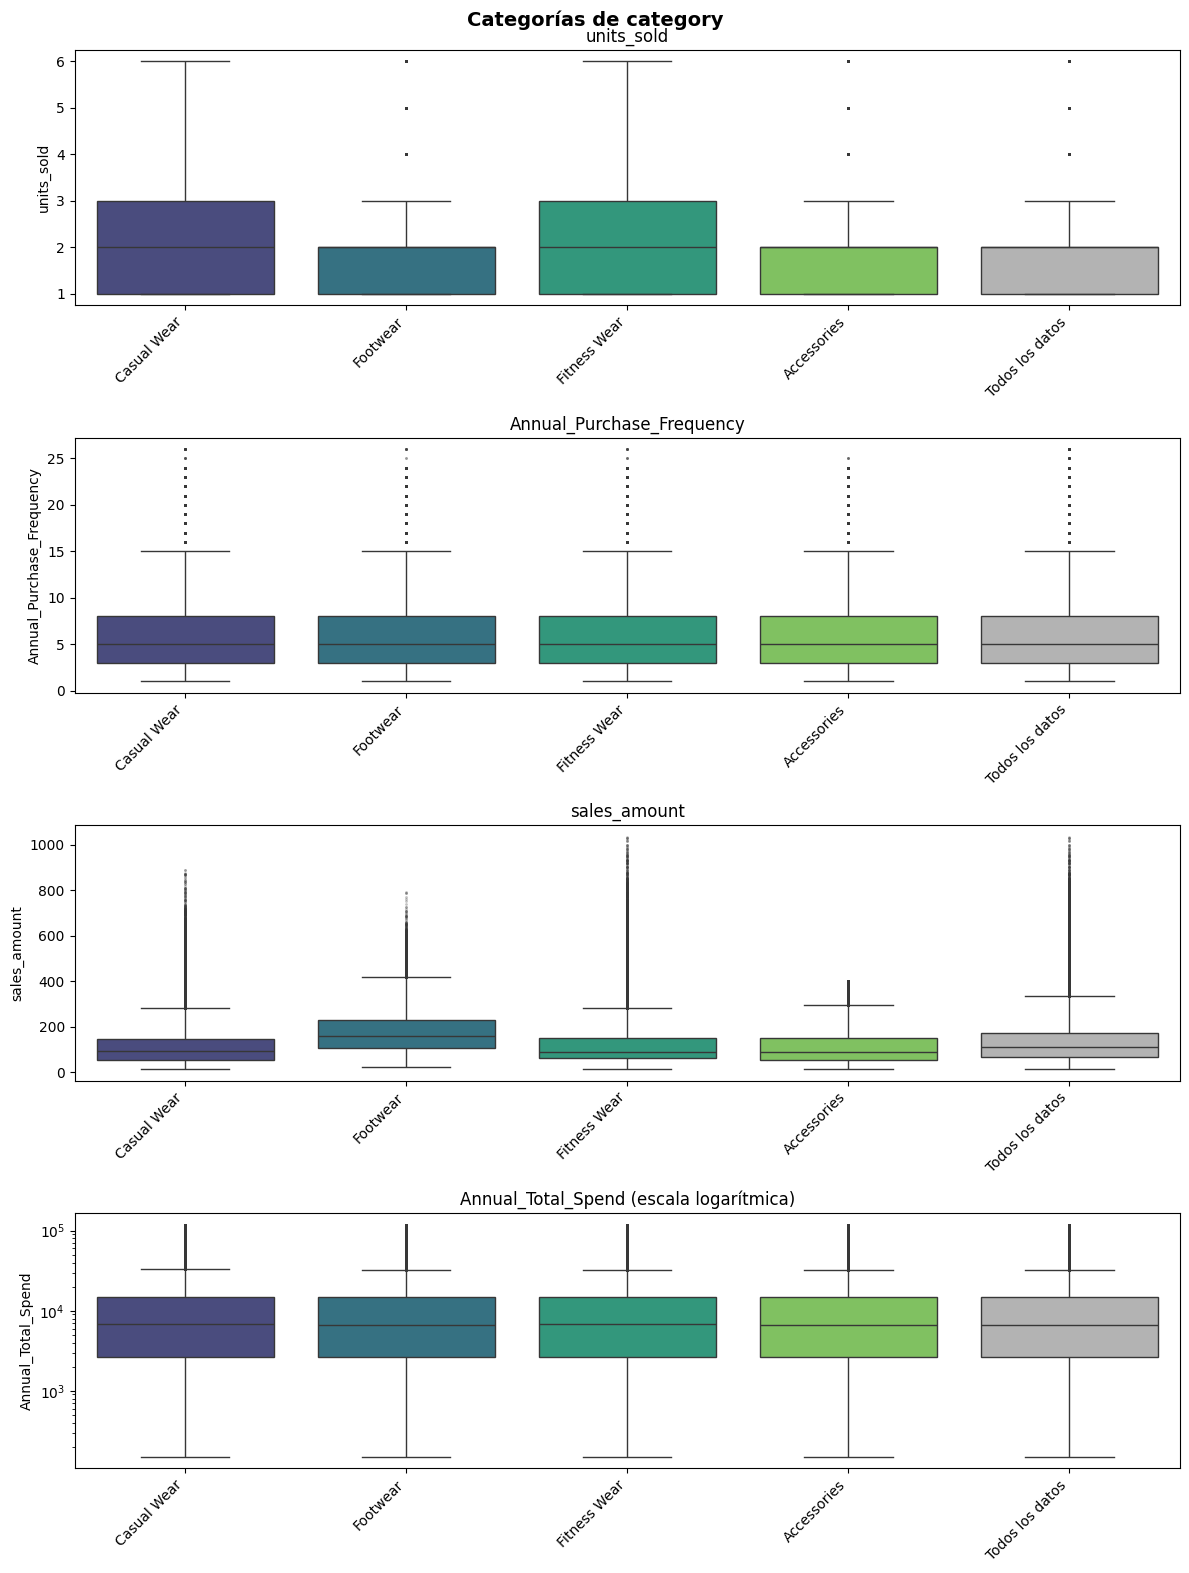

subcategory: Regla del 70% aplicada, se muestran 8 categorías y el resto se agrupa en "Otras".


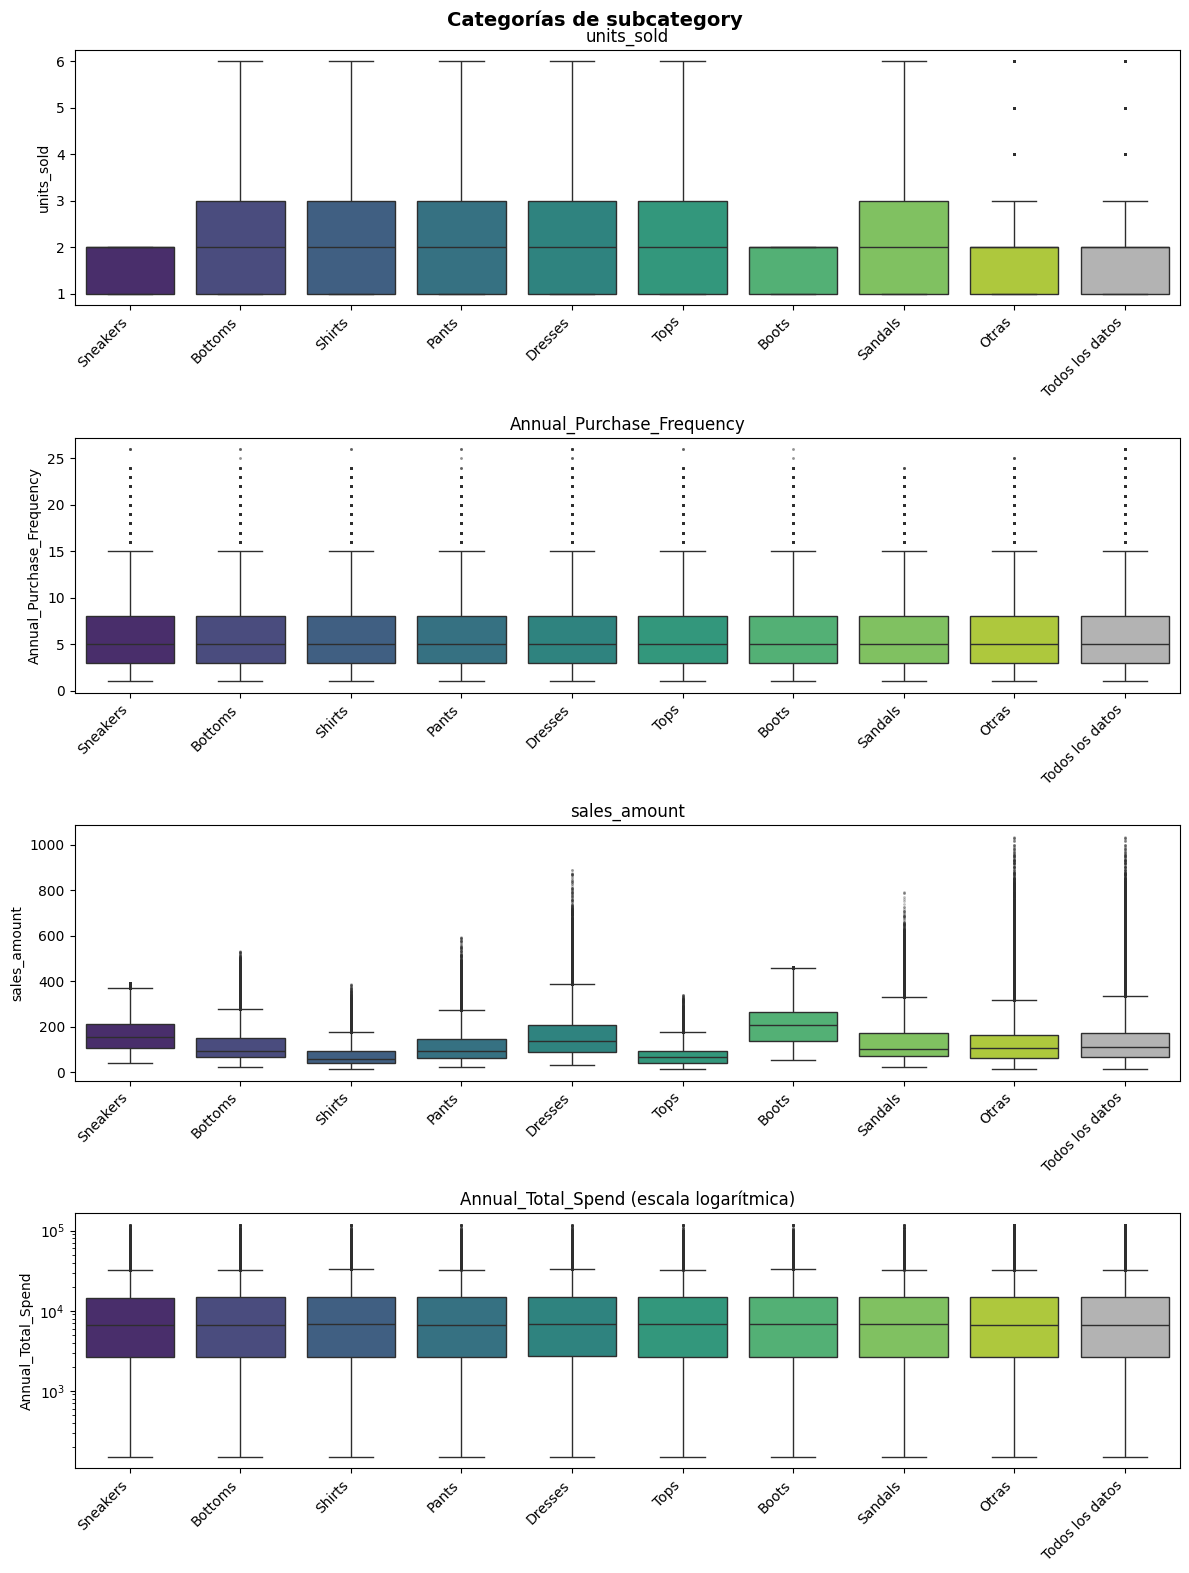

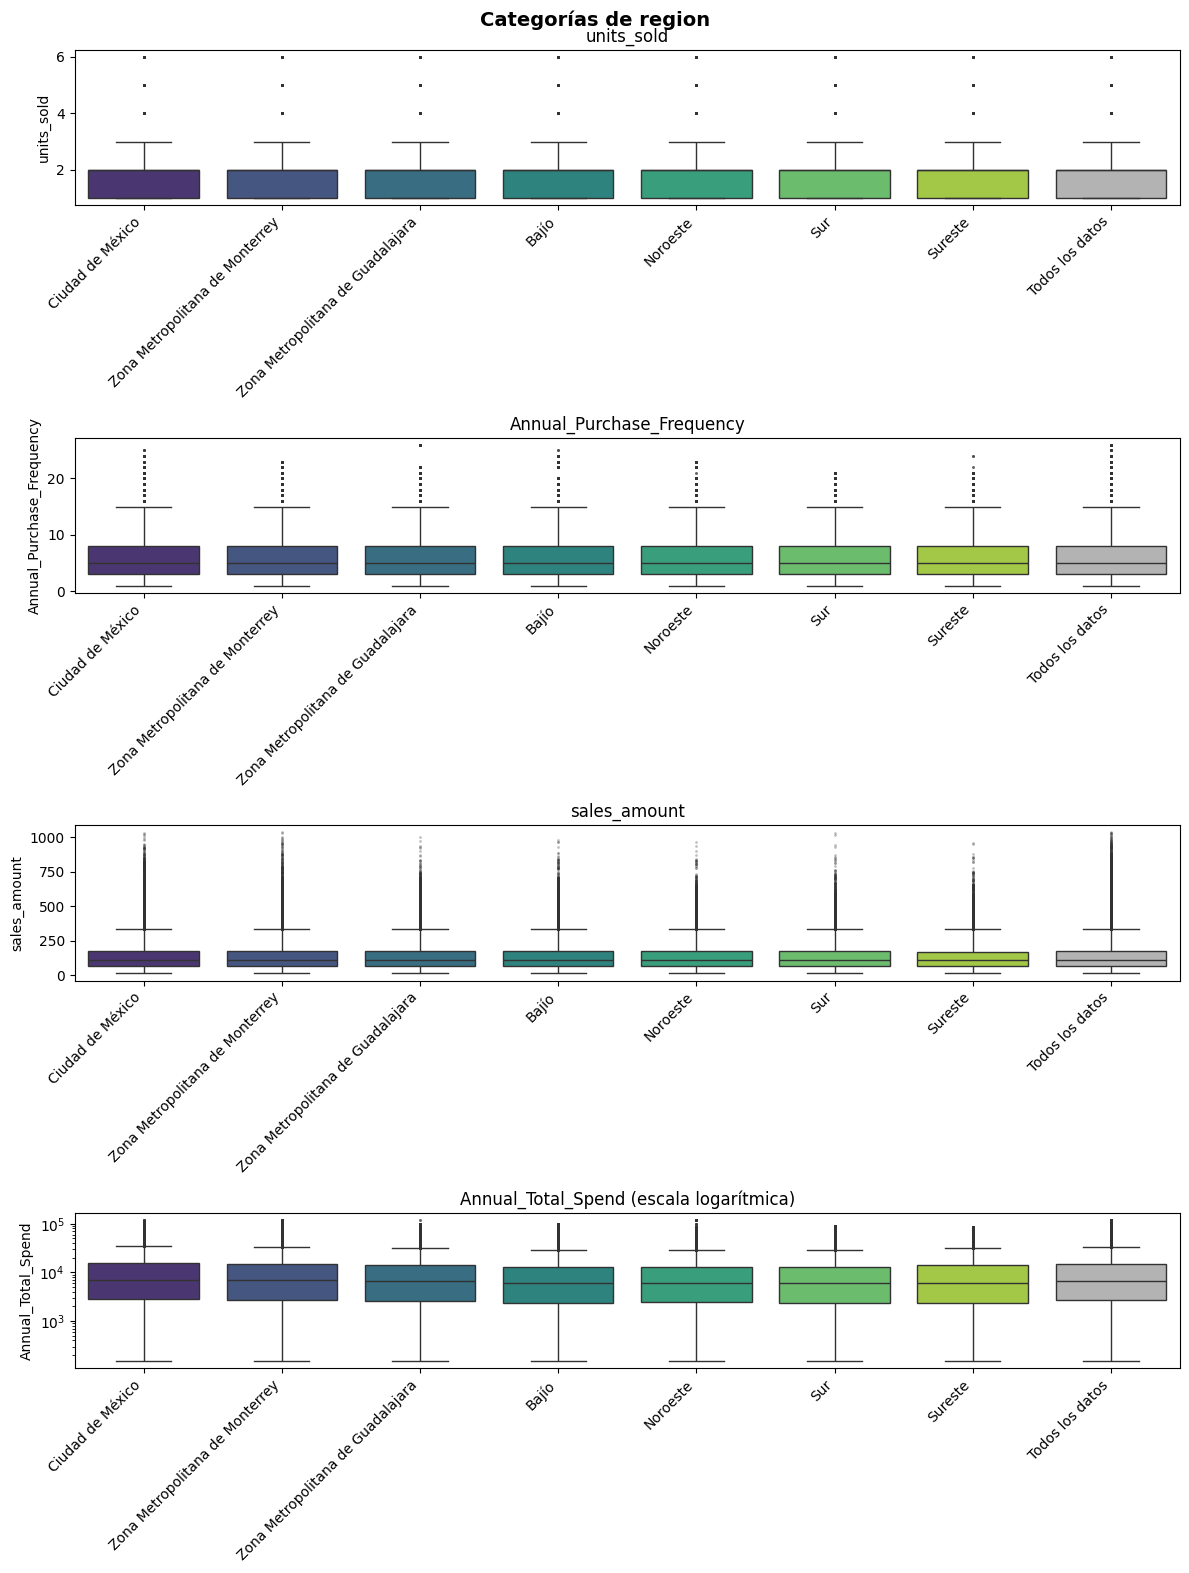

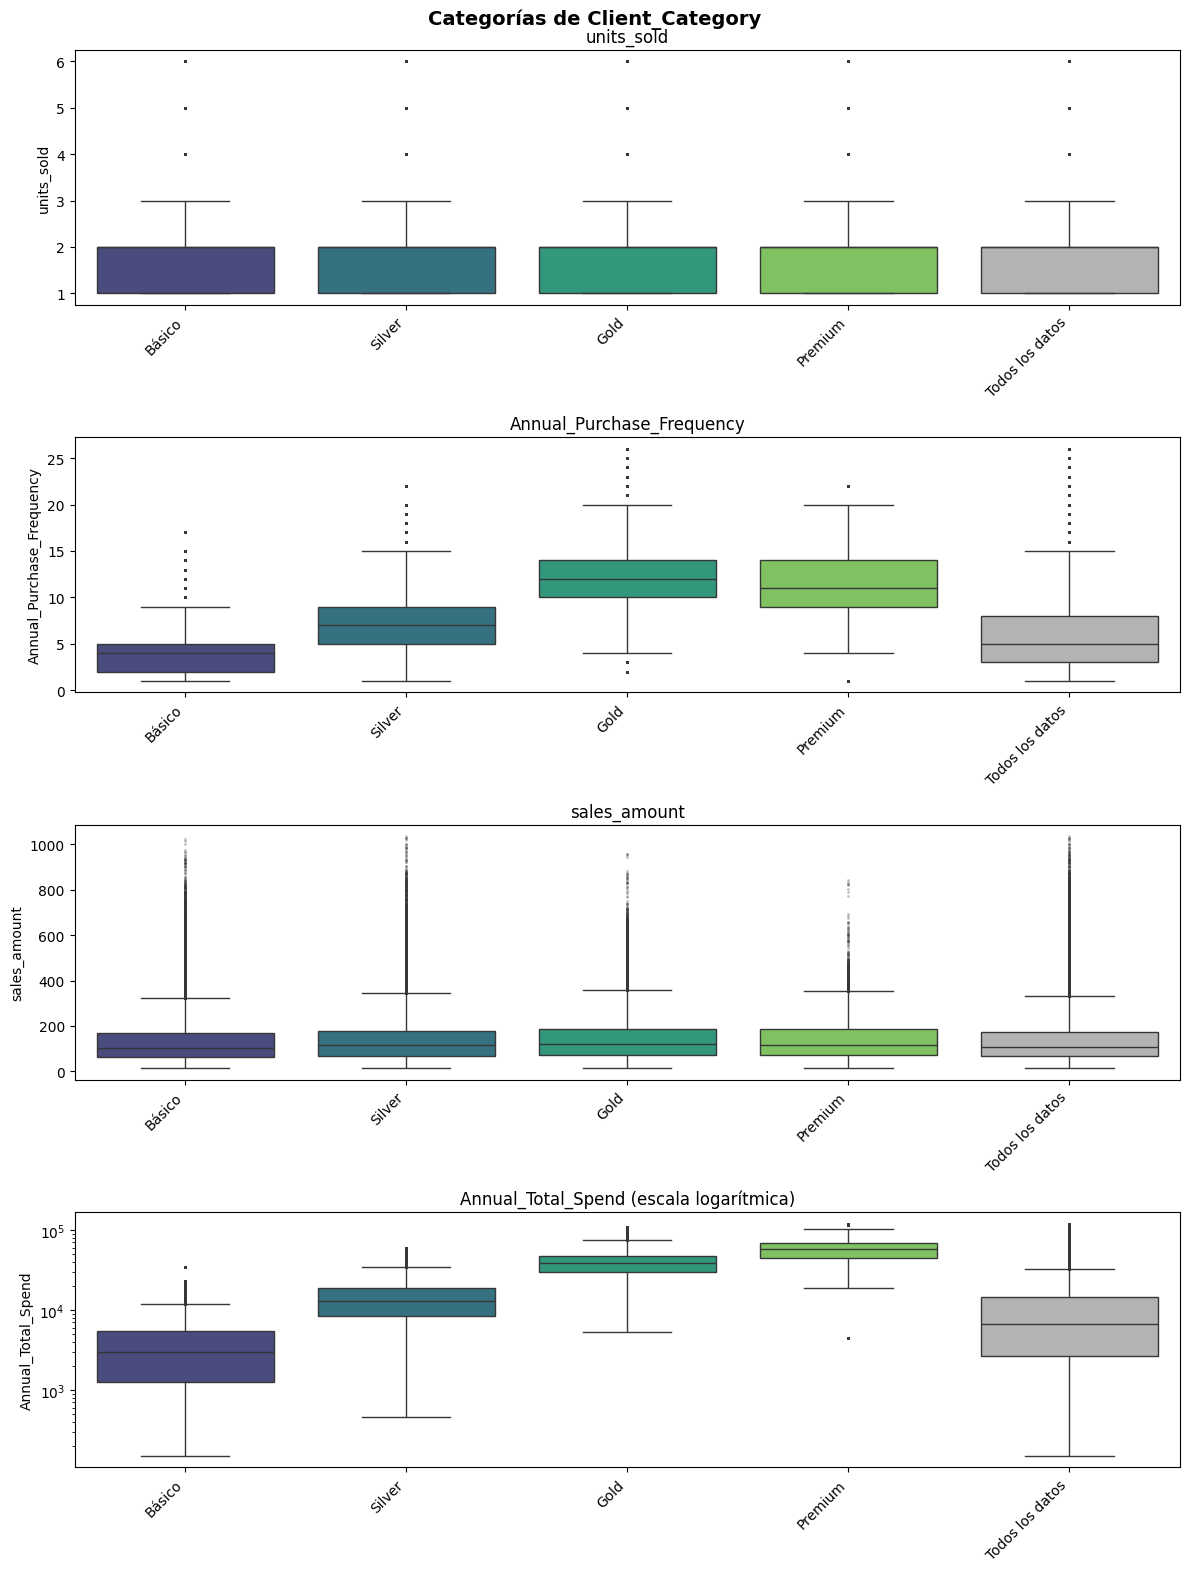

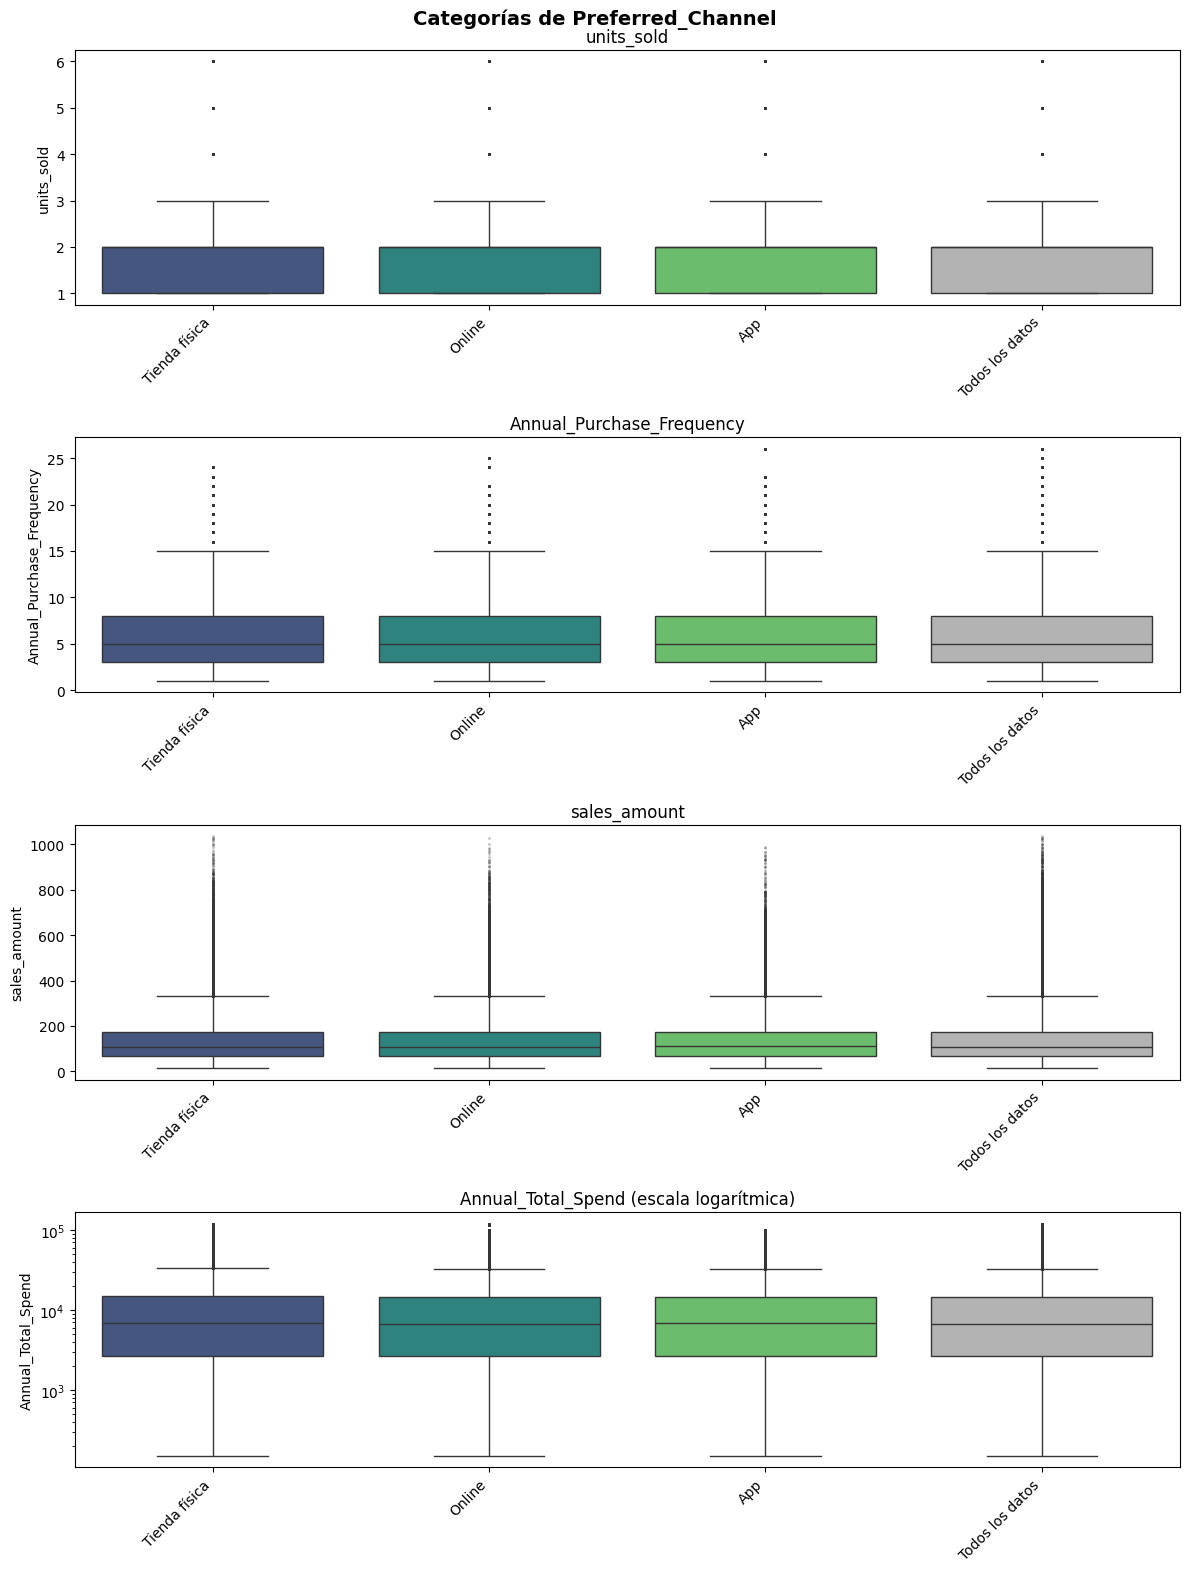

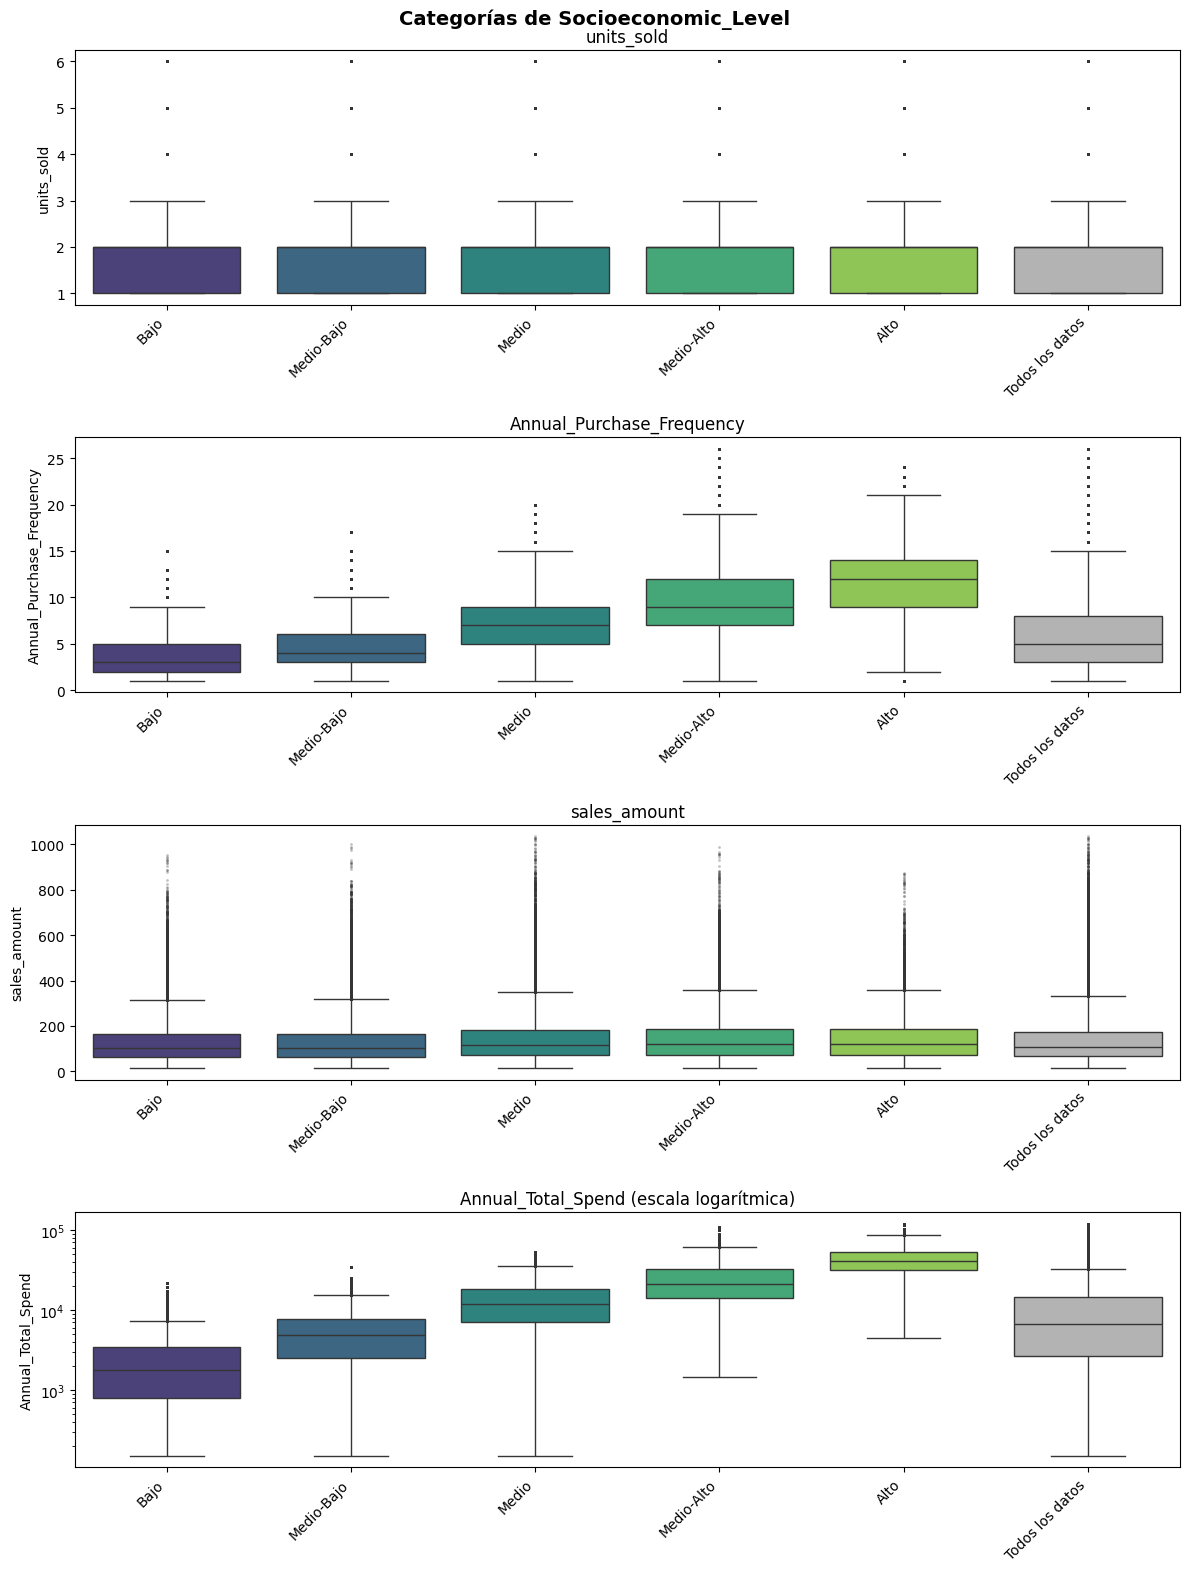

In [ ]:
cuantitativas_cruce_micro = ['units_sold', 'Annual_Purchase_Frequency', 'sales_amount', 'Annual_Total_Spend']

analisis_boxplot_cuanti_cuali(data_DanuStore_Diario, variables_cualitativas, cuantitativas_cruce_micro, Orden=orden_categorias, Peso='units_sold')

## VI. Análisis de Edades de los Clientes

`Age` es un atributo del cliente, pero en el Dataframe Micro se repite en cada transacción. Si se grafica directo, los clientes que compran más veces pesan más. Por eso se construye una tabla de **clientes únicos** (una fila por `client_id`) para describir la edad de la base de clientes, y aparte se usa el Dataframe completo para ver **cuánto vende** cada rango de edad.

In [ ]:
columnas_cliente = ['client_id', 'Age', 'Gender', 'Client_Category', 'Socioeconomic_Level', 'Preferred_Channel',
                    'Annual_Purchase_Frequency', 'Annual_Total_Spend']

clientes = data_DanuStore_Diario.drop_duplicates('client_id')[columnas_cliente].copy()

rangos_edad = ['<25', '25-34', '35-44', '45-54', '55-64', '65+']
clientes['Rango_Edad'] = pd.cut(clientes['Age'], bins=[0, 24, 34, 44, 54, 64, np.inf], labels=rangos_edad).astype(str)

print('Transacciones: ', len(data_DanuStore_Diario))
print('Clientes únicos: ', len(clientes))
display(clientes['Age'].describe())

### 6.1 Distribución de Edades (clientes únicos)

In [ ]:
analisis_histograma(clientes, ['Age'])

orden_edad = {'Rango_Edad': rangos_edad}
grafica_frecuencia(clientes, ['Rango_Edad'], Orden=orden_edad)

### 6.2 Edad por Segmento de Cliente

In [ ]:
analisis_boxplot_cuanti_cuali(clientes, ['Gender', 'Client_Category', 'Socioeconomic_Level', 'Preferred_Channel'], ['Age'],
                             Orden=orden_categorias)

### 6.3 Valor del Cliente por Rango de Edad

In [ ]:
analisis_boxplot_cuanti_cuali(clientes, ['Rango_Edad'], ['Annual_Purchase_Frequency', 'Annual_Total_Spend'], Orden=orden_edad)

### 6.4 Ventas por Rango de Edad (nivel transacción)

In [ ]:
data_DanuStore_Diario['Rango_Edad'] = pd.cut(data_DanuStore_Diario['Age'], bins=[0, 24, 34, 44, 54, 64, np.inf],
                                             labels=rangos_edad).astype(str)

grafica_frecuencia(data_DanuStore_Diario, ['Rango_Edad'], Orden=orden_edad)
grafica_frecuencia(data_DanuStore_Diario, ['Rango_Edad'], Orden=orden_edad, Peso='sales_amount')

## VII. Stock vs. Unidades Esperadas (Nivel Macro)

Se compara el inventario disponible (`stock`) contra la demanda proyectada (`units_expected`) y lo realmente vendido (`units_sold`). La columna `percentage` es `stock / units_expected × 100`: arriba de 100 significa que hay más inventario que demanda esperada. Se agrega `Exceso_Stock = stock - units_expected` para verlo en unidades.

In [ ]:
mensual = data_DanuStore_Mensual.copy()
mensual['fecha'] = pd.to_datetime(mensual['month'] + ' ' + mensual['year'].astype(str), format='%B %Y')
mensual['Exceso_Stock'] = mensual['stock'] - mensual['units_expected']

display(mensual[['stock', 'units_expected', 'units_sold', 'percentage', 'Exceso_Stock']].describe())

print(f'Registros con stock menor a lo esperado: {(mensual["stock"] < mensual["units_expected"]).sum():,} '
      f'({(mensual["stock"] < mensual["units_expected"]).mean() * 100:.2f}%)')

### 7.1 Relación Stock vs. Esperado

In [ ]:
plt.figure(figsize=(8, 8))
sns.scatterplot(data=mensual, x='units_expected', y='stock', hue='category', palette='viridis', s=8, alpha=0.4)

limite = max(mensual['units_expected'].max(), mensual['stock'].max())
plt.plot([0, limite], [0, limite], 'k--', linewidth=1.5, label='Stock = Esperado')

plt.title('Stock vs. Unidades Esperadas')
plt.xlabel('units_expected')
plt.ylabel('stock')
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

analisis_histograma(mensual, ['percentage'])

### 7.2 Esperado, Stock y Vendido por Categoría y Región

Se usa el **promedio por registro** (producto-región-mes), ya que sumar stock de distintos meses no tiene sentido.

In [ ]:
def grafica_stock_esperado(DataFrame, Columnas, Medidas=['units_expected', 'stock', 'units_sold']):
  for i in Columnas:
    resumen = DataFrame.groupby(i)[Medidas].mean().sort_values('stock', ascending=False).reset_index()
    resumen = resumen.melt(id_vars=i, var_name='Medida', value_name='Promedio')

    plt.figure(figsize=(12, 5))
    ax = sns.barplot(data=resumen, x=i, y='Promedio', hue='Medida', palette='viridis')

    for barras in ax.containers:
      ax.bar_label(barras, fmt='{:,.0f}', fontsize=7, padding=2)

    ax.margins(y=0.15)
    plt.title(f'Promedio de Esperado, Stock y Vendido por: {i}')
    plt.xlabel(i)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

grafica_stock_esperado(mensual, variables_cualitativas_macro)

### 7.3 Evolución Mensual

In [ ]:
tendencia = mensual.groupby('fecha')[['units_expected', 'stock', 'units_sold']].sum()

plt.figure(figsize=(12, 5))
for j in tendencia.columns:
  plt.plot(tendencia.index, tendencia[j], marker='o', label=j)

plt.title('Evolución Mensual: Esperado vs. Stock vs. Vendido')
plt.xlabel('Mes')
plt.ylabel('Unidades')
plt.ticklabel_format(axis='y', style='plain')
plt.legend()
plt.tight_layout()
plt.show()

### 7.4 Sobrestock por Categoría y Región

In [ ]:
analisis_boxplot_cuanti_cuali(mensual, variables_cualitativas_macro, ['percentage', 'Exceso_Stock'], Peso='units_sold')